# Descriptive Analysis Notebook — including statistical tests

This notebook summarizes baseline characteristics and explores differences between patients including statistical tests

New data added to Database 23-02-2026


In [34]:
# the necessary libraries for data manipulation, visualization, and modeling
#!pip install pandas
#pip install numpy
#pip install matplotlib
#pip install scikit-learn
#pip install openpyxl
#pip install seaborn
#pip install statsmodels
#pip install patsy

In [35]:
# === Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
from pathlib import Path
# Plotstijl
plt.style.use('seaborn-v0_8')
sns.set_context('talk')

# Helper: display settings
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


In [36]:
# Directories for reports, plots, tables, and data
REPORT_DIR = Path('descriptive_report')
PLOTS_DIR = REPORT_DIR / 'plots'
TABLES_DIR = REPORT_DIR / 'tables'
TABLES_DATA_DIR = Path('tables_data')
TABLES_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTDIR = Path('output')
OUTDIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Report folders created under: {REPORT_DIR.resolve()}")


Report folders created under: C:\Users\Talko Dijkhuis\Hanze\DT Data Gedreven Zorg-Prehabilitatie Isala - Documents\Analyse\descriptive_report


In [37]:

# Paden naar bestanden (aanpassen indien nodig)

DATA_PATH = 'Data/Database prehabilitatie Isala.xlsx'

# Inladen codeboek en data
df = pd.read_excel(DATA_PATH, engine='openpyxl')

print('Data shape   :', df.shape)


Data shape   : (556, 115)


Duration <> null anders is de operatie nog niet geweest

In [38]:
#count rows df
N = df.shape[0]
print(f"Dataset geladen met {N} rijen en {df.shape[1]} kolommen.")
# remove rows with missing outcome for duration of surgery
df = df[~df['Duration_surgery'].isna()].copy()
N = df.shape[0]
print(f"Dataset zonder duration geladen met {N} rijen en {df.shape[1]} kolommen.")
# filter on tumor location on 'Colon' and Rectum  
df = df[df['Tumor_location'].isin(['Colon', 'Rectum'])].copy()
N = df.shape[0]
print(f"Dataset gefilterd op locatie Colon en Rectum met {N} rijen en {df.shape[1]} kolommen.")
# date discharge is not missing
df = df[~df['Date_discharge'].isna()].copy()
N = df.shape[0]
print(f"Dataset zonder missing discharge date geladen met {N} rijen en {df.shape[1]} kolommen.")



Dataset geladen met 556 rijen en 115 kolommen.
Dataset zonder duration geladen met 340 rijen en 115 kolommen.
Dataset gefilterd op locatie Colon en Rectum met 340 rijen en 115 kolommen.
Dataset zonder missing discharge date geladen met 340 rijen en 115 kolommen.


In [39]:
# === Data Cleaning & Preprocessing ===

# Datums → datetime
date_cols = [
    'Hb_t0_date',
    'Hb_t1_date',
    'SRT_t0_date',
    'SRT_t1_date',
    'intakedatum_appointment_start_date',
    'number_sessions',
    'Date_admission',
    'Date_discharge',
    'Date_surgery',
    'LOS_minutes',
    'IC_end',
    'IC_start',
    'Readmission_date',
    'Readmission_discharge'
]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

binary_vars = [
               'Compression_stockings',
               'Corticosteroids',
               'Crutch',
               'Hearing_aid',
               'Mobility_scooter',
               'Two_stairs',
               'Visual_aid',
               'Walking_aid',
               'Walking_stick',
               'Wheelchair',
               'Home_adaptations',
               'Previous_cognitive',
               '6MWT',
               'SRT_able',
               'complicaties_dcra_form_entries_value_text',
               'Feeding_tube',
               'Complication',
               'ICU',
               'Readmissions',
               'Reoperation',
               'Anemia_treatment',
               'bindweefselziekte_form_entries_value_text',
               'cerebrovasculaire_aandoening_form_entries_value_text',
               'chronische_longziekte_form_entries_value_text',
               'congestief_hartfalen_form_entries_value_text',
               'dementie_form_entries_value_text',
               'gastrointestinaal_ulcuslijden_form_entries_value_text',
               'hiv_aids_form_entries_value_text',
               'myocardinfarct_form_entries_value_text',
               'nierziekte_form_entries_value_text',
               'para_hemiplegie_form_entries_value_text',
               'perifeer_vaatlijden_aneurysma_form_entries_value_text',
]
for c in binary_vars:
    if c in df.columns:
        #kan ook 'bool' zijn maar 'category' is vaak handiger voor analyses
        df[c] = df[c].astype('category')

# Multi-level categorical
multi_cat_vars = ['gender',
                  'Alcohol',
                  'Drugs',
                  'Smoking',
                  'Functioning',
                  'Personal_care',
                  'Elective',
                  'Surgeon',
                  'Tumor_location',
                  'Type_anesthesia',
                  'Type_surgery',
                  'Admission_source',
                  'Discharge_source',
                  'Reoperation_type',
                  'validation_surgery',
                  'diabetes_mellitus_form_entries_value_text',
                  'leverziekten_form_entries_value_text',
                  'maligniteit_form_entries_value_text',
                  'Sort'
]
for c in multi_cat_vars:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Integer

numeric_hint = ['year_of_birth',
                'Age',
                'Stopped_since',
                'Length',
                'Albumin',
                'CRP',
                'Creatinine',
                'Ferritin',
                'HbA1c',
                'Trans_sat',
                'Second_rise',
                'Secondrise_t1',
                'HADS',
                'PG_SGA_t0',
                'VSAQ',
                '6MWT_m',
                'SRT_t0',
                'SRT_t1',
                'Duration_surgery',
                'Complications_number',
                'ICU_los',
                'LOS',
               'Readmission_los',
               
               
]
for c in numeric_hint:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], downcast='integer', errors='coerce')



#float
float_hint = ['Handgrip_t1',
              'Handgrip_strength',
              '5TSTS',
              '5TSTS_t1',
              'Transferrin',
              'Hb_t0',
              'Hb_t1',
              'BMI',
              'Weight'
]
for c in float_hint:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], downcast='float', errors='coerce')

# Controleer dtypes in texteditor
df.dtypes
# get the object columns
object_cols = df.select_dtypes(include='object').columns
# ============================================  

# Convert remaining object columns to appropriate dtypes
# Categorical/ordinal
categorical_object_cols = [
    'Clavien_dindo', 'Complication_type', 'neoadjuvant', 'mortality_30days',
    'CTD', 'CVA', 'CHF', 'COPD', 'DEM', 'DM', 'PUD', 'AIDS', 'LYM', 'LEUK', 'TUM', 'LIVER_DIS', 'MI', 'CKD', 'HEMIP', 'PAD'
]
for c in categorical_object_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

# Numeric
numeric_object_cols = ['number_sessions_complete']
for c in numeric_object_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# pseudo_id and Procedure_surgery_raw remain as object (string/text)

In [40]:

# ============================================
# Medische drempelwaarden en aanvullende categorisaties
# (voor BMI, Hb, 5TSTS, handgrip, SRT fitness)
# ============================================
import pandas as pd
import numpy as np
import json
from pathlib import Path

# ---- Kernkolommen in dataset ----
COL_SEX = 'gender'     # verwacht 'M'/'F' of 'm'/'f'
COL_AGE = 'Age'        # (jaren), niet strikt nodig voor drempels hier
COL_LEN = 'Length'     # (cm)
COL_WGT = 'Weight'     # (kg)

# ---- Variabelen (indien aanwezig in de data) ----
V_HB_T0   = 'Hb_t0'
V_HB_T1   = 'Hb_t1'
V_5TSTS_T0= '5TSTS'
V_5TSTS_T1= '5TSTS_t1'
V_HG_T0   = 'Handgrip_strength'
V_HG_T1   = 'Handgrip_t1'
V_SRT_T0  = 'SRT_t0'
V_SRT_T1  = 'SRT_t1'

# ---- Hb referentie-set (keuze): 'medscape' of 'sanquin' ----

HB_RANGES = {
      # mmol/L
    'prehabilitatie' : {'M': (8.0, 11.0), 'F': (7.5, 10.0)}   # mmol/L
}

# ---- 5TSTS cut-offs (klinisch) ----
CUT_5TSTS_SCREEN = 12.0  # ≥12s -> verdere valrisico-screening
CUT_5TSTS_HIGH   = 15.0  # ≥15s -> verhoogd valrisico

# ---- EWGSOP2 handgrip cut-offs ----
CUT_HG_MALE   = 27.0  # kg
CUT_HG_FEMALE = 16.0  # kg

# ---- SRT W/kg fitheidscut-off ----
CUT_SRT_WKG_UNFIT = 2.1  # W/kg -> <2.1 onfit; >=2.1 fit



# Normaliseer geslacht naar 'M'/'F'
df[COL_SEX] = (
    df[COL_SEX]
    .astype(str)
    .str.strip()
    .str.upper()
    .str[0]
    .replace({'V': 'F'})  # Nederlands 'Vrouw' -> F
)

# ----------------- BMI -----------------
def compute_bmi(length_cm, weight_kg):
    if pd.isna(length_cm) or pd.isna(weight_kg) or length_cm <= 0:
        return np.nan
    h_m = length_cm / 100.0
    return weight_kg / (h_m ** 2) if h_m > 0 else np.nan

df['BMI'] = df.apply(lambda r: compute_bmi(r.get(COL_LEN), r.get(COL_WGT)), axis=1)

def bmi_category(bmi):
    if pd.isna(bmi):
        return np.nan
    if bmi < 18.5:   return 'Underweight'
    if bmi < 25.0:   return 'Normal'
    if bmi < 30.0:   return 'Overweight'
    return 'Obesity'

df['BMI_cat'] = df['BMI'].apply(bmi_category)

# ----------------- Hb (geslachtsafhankelijk) -----------------
def hb_category(hb, sex, ref='prehabilitatie'):
    if pd.isna(hb) or sex not in ('M', 'F'):
        return np.nan
    lo, hi = HB_RANGES[ref][sex]
    if hb < lo:  return 'Low'
    if hb > hi:  return 'High'
    return 'Normal'

for v in [V_HB_T0, V_HB_T1]:
    if v in df.columns:
        df[f'{v}_cat'] = [hb_category(hb, sex) for hb, sex in zip(df[v], df[COL_SEX])]

# ----------------- 5TSTS -----------------
def stsst_category(seconds):
    if pd.isna(seconds): 
        return np.nan
    if seconds >= CUT_5TSTS_HIGH:    return 'High_risk'
    if seconds >= CUT_5TSTS_SCREEN:  return 'Elevated'
    return 'Normal'

for v in [V_5TSTS_T0, V_5TSTS_T1]:
    if v in df.columns:
        df[f'{v}_cat'] = df[v].apply(stsst_category)
        df[f'{v}_flag_12s_plus'] = np.where(df[v].ge(CUT_5TSTS_SCREEN), 1, 0).astype('float64')
        df[f'{v}_flag_15s_plus'] = np.where(df[v].ge(CUT_5TSTS_HIGH),   1, 0).astype('float64')

# ----------------- Handknijpkracht (EWGSOP2) -----------------
def handgrip_low(hg, sex):
    if pd.isna(hg) or sex not in ('M','F'):
        return np.nan
    cut = CUT_HG_MALE if sex == 'M' else CUT_HG_FEMALE
    return 'Low' if hg < cut else 'Normal'

for v in [V_HG_T0, V_HG_T1]:
    if v in df.columns:
        df[f'{v}_cat'] = [handgrip_low(val, sex) for val, sex in zip(df[v], df[COL_SEX])]

# ----------------- SRT: W/kg en fitheid -----------------

import numpy as np
import pandas as pd
import re

# Hulpfunctie: zet een kolom veilig om naar float (accepteert decimale komma's, verwijdert niet-cijfertekens)
def to_float(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    # vervang decimale komma's door punt
    s = s.str.replace(',', '.', regex=False)
    # verwijder alles behalve cijfers, minteken en punt (bv. '175 W' -> '175', '2.3*' -> '2.3')
    s = s.str.replace(r'[^0-9\.\-]+', '', regex=True)
    return pd.to_numeric(s, errors='coerce')

# Zorg dat gewicht numeriek is
df[COL_WGT] = to_float(df[COL_WGT])

# Bereken SRT W/kg + fitheidsklasse zonder dtype-conflicts
for v in [V_SRT_T0, V_SRT_T1]:
    if v in df.columns:
        # 1) Coerce SRT-kolom naar float
        srt_num = to_float(df[v])

        # 2) W/kg: deling zonder fouten + alleen waar gewicht > 0
        wkg_col = f'{v}_wkg'
        df[wkg_col] = srt_num.div(df[COL_WGT])
        df.loc[~(df[COL_WGT] > 0), wkg_col] = np.nan   # voorkom deling door 0/negatief
        df.loc[srt_num.isna(), wkg_col] = np.nan        # geen SRT-waarde = NaN

        # 3) Fitheidsclassificatie o.b.v. medische cut-off (2.1 W/kg)
        #    Unfit < 2.1 ; Fit >= 2.1 ; NaN blijft NaN
        fit_col = f'{v}_fitness_cat'
        df[fit_col] = df[wkg_col].apply(
            lambda x: 'Unfit' if pd.notna(x) and x < CUT_SRT_WKG_UNFIT 
                      else ('Fit' if pd.notna(x) else np.nan)
        )

# (optioneel) snelle controle op dtypes en voorbeeldregels
cols_check = []
for v in [V_SRT_T0, V_SRT_T1]:
    if v in df.columns:
        cols_check.extend([v, f'{v}_wkg', f'{v}_fitness_cat'])
cols_check = [c for c in cols_check if c in df.columns]



# ----------------- Logging drempels -----------------
thresholds_used = {
    'BMI': {'Underweight': '<18.5', 'Normal': '18.5–24.9', 'Overweight': '25.0–29.9', 'Obesity': '≥30.0'},
        'Hb_ranges_mmol_per_L': {'M': '(8.0, 11.0)', 'F': '(7.5, 10.0)'},
    '5TSTS_seconds': {'Elevated_screening': f'≥{CUT_5TSTS_SCREEN}', 'High_risk': f'≥{CUT_5TSTS_HIGH}'},
    'Handgrip_EWGSOP2_kg': {'Male_low_if': f'<{CUT_HG_MALE}', 'Female_low_if': f'<{CUT_HG_FEMALE}'},
    'SRT_W_per_kg': {'Unfit_if': f'<{CUT_SRT_WKG_UNFIT}', 'Fit_if': f'≥{CUT_SRT_WKG_UNFIT}'}
}

with pd.ExcelWriter(TABLES_DATA_DIR / 'thresholds_used_medical.xlsx', engine='openpyxl') as writer:
    thresholds_used_df = pd.DataFrame([
        {'variable': var, 'category_or_flag': cat, 'threshold': thresh}
        for var, cats in thresholds_used.items()
        for cat, thresh in cats.items()
    ])
    thresholds_used_df.to_excel(writer, index=False, sheet_name='Thresholds')   
    
# ----------------- Samenvatting -----------------
summary_rows = []
for c in df.columns:
    if c.endswith('_cat') or c.endswith('_flag_12s_plus') or c.endswith('_flag_15s_plus'):
        counts = df[c].value_counts(dropna=False)
        total = counts.sum()
        for k, v in counts.items():
            pct = 100.0 * v / total if total else np.nan
            summary_rows.append({'variable': c, 'category_or_flag': str(k), 'n': int(v), 'pct': round(pct, 1)})
summary = pd.DataFrame(summary_rows).sort_values(['variable', 'category_or_flag'])

# ----------------- Wegschrijven -----------------
df.to_excel(TABLES_DATA_DIR  / 'categorized_results_medical.xlsx', index=False)
summary.to_csv(TABLES_DATA_DIR/ 'categorization_summary_medical.csv', index=False)

print("Gereed. Output-map:", OUTDIR.resolve())


Exception ignored in: <function ZipFile.__del__ at 0x000001AFC51F0720>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\zipfile.py", line 1894, in __del__
    self.close()
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\zipfile.py", line 1911, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Gereed. Output-map: C:\Users\Talko Dijkhuis\Hanze\DT Data Gedreven Zorg-Prehabilitatie Isala - Documents\Analyse\output


In [41]:

# ============================================================
# Δ-categorisatie (t1 - t0) op basis van medische drempels
# Vereist dat de vorige stap de *_cat kolommen en SRT_*_wkg heeft gemaakt
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path



# ------- Helper-functies voor Δ-categorisatie -------

# Hb: categorieën t.o.v. 'Normal' (Low/High = abnormaal)
def hb_delta_cat(c0, c1):
    if pd.isna(c0) or pd.isna(c1):
        return np.nan
    if c0 == 'Normal' and c1 == 'Normal':
        return 'Stable_normal'
    if c0 != 'Normal' and c1 == 'Normal':
        return 'Improved_normalized'
    if c0 == 'Normal' and c1 != 'Normal':
        return 'Worsened_to_Low'
    # low -> low
    if c0 == 'Low' and c1 == 'Low':
        return 'Stable_low'
    return 'Shifted_abnormal'  # Low <-> High

# Generieke 2-klassen Δ (bv. Handgrip: Normal vs Low; SRT: Fit vs Unfit)
def binary_delta_cat(c0, c1, good_label='Normal', bad_label='Low'):
    if pd.isna(c0) or pd.isna(c1):
        return np.nan
    if c0 == bad_label and c1 == good_label:
        return 'Improved'
    if c0 == good_label and c1 == bad_label:
        return 'Worsened'
    return 'Stable'

# Ordinale Δ (bv. 5TSTS: Normal < Elevated_≥12s < High_risk_≥15s)
def ordinal_delta_cat(c0, c1, order):
    if pd.isna(c0) or pd.isna(c1):
        return np.nan
    # Onbekende labels -> NaN
    if c0 not in order or c1 not in order:
        return np.nan
    r0, r1 = order[c0], order[c1]
    if r1 < r0:
        return 'Improved'
    if r1 > r0:
        return 'Worsened'
    return 'Stable'

# Numerieke Δ en Δ%
def add_numeric_deltas(df, t0, t1, base_name):
    if t0 in df.columns and t1 in df.columns:
        df[f'{base_name}_delta'] = (df[t1] - df[t0])/1000000
        # Relatieve Δ in % (veilig: deel door |t0|, voorkom 0)
        denom = df[t0].replace(0, np.nan).abs()
        df[f'{base_name}_delta_pct'] = (df[f'{base_name}_delta'] / denom * 100.0).round(2)
    return df

# ------- PAREN & MAPPINGS -------
# Hb
HB_T0_CAT = 'Hb_t0_cat'
HB_T1_CAT = 'Hb_t1_cat'

# 5TSTS (ordineer risico)
STS_ORDER = {'Normal': 0, 'Elevated_≥12s': 1, 'High_risk_≥15s': 2}

# Handgrip (EWGSOP2 Low vs Normal)
# Handgrip_strength -> baseline; Handgrip_t1 -> follow-up
HG_T0 = 'Handgrip_strength'; HG_T1 = 'Handgrip_t1'
HG_T0_CAT = f'{HG_T0}_cat'; HG_T1_CAT = f'{HG_T1}_cat'

# 5TSTS variabelen
STS_T0 = '5TSTS'; STS_T1 = '5TSTS_t1'
STS_T0_CAT = f'{STS_T0}_cat'; STS_T1_CAT = f'{STS_T1}_cat'

# SRT (W/kg & fitness_cat)
SRT_T0 = 'SRT_t0'; SRT_T1 = 'SRT_t1'
SRT_T0_WKG = f'{SRT_T0}_wkg'; SRT_T1_WKG = f'{SRT_T1}_wkg'
SRT_T0_FIT = f'{SRT_T0}_fitness_cat'; SRT_T1_FIT = f'{SRT_T1}_fitness_cat'

# ------- 1) NUMERIEKE Δ TOEVOEGEN (t1 - t0) -------
pairs_numeric = [
    # (t0, t1, base_name)
    ('Hb_t0', 'Hb_t1', 'Hb'),
    (HG_T0,   HG_T1,   'Handgrip'),
    (STS_T0,  STS_T1,  '5TSTS'),
    (SRT_T0_WKG, SRT_T1_WKG, 'SRT_wkg'),
]

for t0, t1, base in pairs_numeric:
    if t0 in df.columns and t1 in df.columns:
        add_numeric_deltas(df, t0, t1, base)

# ------- 2) CATEGORIE-Δ TOEVOEGEN -------
# Hb
if HB_T0_CAT in df.columns and HB_T1_CAT in df.columns:
    df['Hb_delta_cat'] = [hb_delta_cat(c0, c1) for c0, c1 in zip(df[HB_T0_CAT], df[HB_T1_CAT])]

# 5TSTS
if STS_T0_CAT in df.columns and STS_T1_CAT in df.columns:
    df['5TSTS_delta_cat'] = [
        ordinal_delta_cat(c0, c1, STS_ORDER) for c0, c1 in zip(df[STS_T0_CAT], df[STS_T1_CAT])
    ]

# Handgrip (Normal vs Low)
if HG_T0_CAT in df.columns and HG_T1_CAT in df.columns:
    df['Handgrip_delta_cat'] = [
        binary_delta_cat(c0, c1, good_label='Normal', bad_label='Low') 
        for c0, c1 in zip(df[HG_T0_CAT], df[HG_T1_CAT])
    ]

# SRT fitness (Fit_≥2.1Wkg vs Unfit_<2.1Wkg)
if SRT_T0_FIT in df.columns and SRT_T1_FIT in df.columns:
    df['SRT_fitness_delta_cat'] = [
        binary_delta_cat(c0, c1, good_label='Fit_≥2.1Wkg', bad_label='Unfit_<2.1Wkg') 
        for c0, c1 in zip(df[SRT_T0_FIT], df[SRT_T1_FIT])
    ]

# ------- 3) SAMENVATTING TELLEN -------
delta_cols = [
    col for col in [
        'Hb_delta_cat',
        '5TSTS_delta_cat',
        'Handgrip_delta_cat',
        'SRT_fitness_delta_cat'
    ] if col in df.columns
]

summary_rows = []
for c in delta_cols:
    vc = df[c].value_counts(dropna=False)
    tot = vc.sum()
    for k, v in vc.items():
        pct = 100.0 * v / tot if tot else np.nan
        summary_rows.append({'delta_variable': c, 'delta_category': str(k), 'n': int(v), 'pct': round(pct, 1)})

delta_summary = pd.DataFrame(summary_rows).sort_values(['delta_variable', 'delta_category'])
delta_summary.to_excel(TABLES_DATA_DIR / 'delta_categorization_summary_medical.xlsx', index=False)

# Werkbestand bijwerken
df.to_excel(TABLES_DATA_DIR / 'categorized_results_medical_with_deltas.xlsx', index=False)

print('Δ-categorisatie gereed.')
print('Samenvatting opgeslagen als:', (OUTDIR / 'delta_categorization_summary_medical.csv').resolve())
print('Dataframe met Δ-kolommen opgeslagen als:', (OUTDIR / 'categorized_results_medical_with_deltas.xlsx').resolve())


Δ-categorisatie gereed.
Samenvatting opgeslagen als: C:\Users\Talko Dijkhuis\Hanze\DT Data Gedreven Zorg-Prehabilitatie Isala - Documents\Analyse\output\delta_categorization_summary_medical.csv
Dataframe met Δ-kolommen opgeslagen als: C:\Users\Talko Dijkhuis\Hanze\DT Data Gedreven Zorg-Prehabilitatie Isala - Documents\Analyse\output\categorized_results_medical_with_deltas.xlsx


In [42]:
# Define t0/t1 variable pairs
'''pairs = [
    ('Hb_t0','Hb_t1','Hb'),
    ('Handgrip_strength','Handgrip_t1','Handgrip'),
    ('5TSTS','5TSTS_t1','5TSTS'),
    ('Second_rise','Secondrise_t1','Secondrise'),
    ('SRT_t0','SRT_t1','SRT')
]'''



"pairs = [\n    ('Hb_t0','Hb_t1','Hb'),\n    ('Handgrip_strength','Handgrip_t1','Handgrip'),\n    ('5TSTS','5TSTS_t1','5TSTS'),\n    ('Second_rise','Secondrise_t1','Secondrise'),\n    ('SRT_t0','SRT_t1','SRT')\n]"

In [43]:

import numpy as np
import pandas as pd

ordinal_specs = {
    "ASA": [1, 2, 3, 4],
    "Surgery_asa": [1, 2, 3, 4],
    "Dyspnea_MRC": [0, 1, 2, 3, 4, 5],
    "Clavien_dindo": [0, 1, 2, 3, 4, 5],
    "KATZ": [0, 1, 2, 3, 4, 5]
}

def coerce_to_ordered(df, specs, sparse_min=5):
    """
    Coerce specified columns to ordered categoricals with explicit levels.
    Return a validation DataFrame with counts and flags.
    """
    records = []
    for col, cats in specs.items():
        if col not in df.columns:
            records.append({
                "variable": col, "status": "missing_in_df",
                "declared_levels": cats, "observed_levels": [],
                "n": 0, "n_missing": np.nan, "sparse_levels": []
            })
            continue

        # numeric conversion with coercion
        df[col] = pd.to_numeric(df[col], errors="coerce")

        # explicit ordered dtype (keeps unused levels)
        dtype = pd.CategoricalDtype(categories=cats, ordered=True)
        df[col] = df[col].astype(dtype)

        # validation stats
        counts = df[col].value_counts(dropna=False).reindex(cats, fill_value=0)
        sparse = [lvl for lvl, n in counts.items() if n < sparse_min]
        observed_levels = [lvl for lvl in cats if counts.loc[lvl] > 0]

        records.append({
            "variable": col,
            "status": "ok",
            "declared_levels": cats,
            "observed_levels": observed_levels,
            "n": int(df[col].notna().sum()),
            "n_missing": int(df[col].isna().sum()),
            "sparse_levels": sparse
        })

    report = pd.DataFrame.from_records(records)
    return df, report

# Example usage:
df, validation = coerce_to_ordered(df, ordinal_specs, sparse_min=5)
display(validation)


,variable,status,declared_levels,observed_levels,n,n_missing,sparse_levels
0,ASA,ok,"[1, 2, 3, 4]","[1, 2, 3, 4]",330,10,[4]
1,Surgery_asa,ok,"[1, 2, 3, 4]","[1, 2, 3, 4]",340,0,[]
2,Dyspnea_MRC,ok,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4]",301,39,[5]
3,Clavien_dindo,ok,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 5]",302,38,"[3, 4, 5]"
4,KATZ,ok,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]",163,177,"[2, 3, 4, 5]"


In [44]:
#non textbook outcome composiet maken

# Binaire mapping voor ja/nee
yn_map = {'ja':1,'nee':0,'Ja':1,'Nee':0,'YES':1,'NO':0,'Yes':1,'No':0}

def map_bin(series):
    s = series.astype('string').str.strip().str.lower()
    return s.map({'ja':1,'nee':0})

# Complication, ICU, Readmissions
for c in ['Complication','ICU','Readmissions','Reoperation']:
    if c in df.columns:
        df[c+'_bin'] = map_bin(df[c])

# LOS drempel (aanpasbaar) Talko: arbitrair op 7 dagen gezet
LOS_THRESHOLD = 7  

# Converteer categorical naar string
df['Tumor_location'] = df['Tumor_location'].astype(str)

# Stel thresholds in
df['LOS_THRESHOLD'] = df['Tumor_location'].apply(
    lambda x: 4 if x == 'Colon' else (5 if x == 'Rectum' else 7)
)

# Binaire kolom maken
df['los_prolonged'] = np.where(df['LOS'].fillna(0) > df['LOS_THRESHOLD'], 1, 0)


# Composiet non_textbook_outcome
# parts_t Talko versie
#parts_t = [x for x in ['Complication_bin','ICU_bin','Reoperation_bin','Readmissions_bin ','los_prolonged'] if x in df.columns]
# parts_d Danielle versie
parts_d = [x for x in ['Readmissions_bin ','los_prolonged'] if x in df.columns]
# maak non_textbook_outcome kolom als 1 als een van de onderdelen 1 is en clavien_dindo > 2 
# Create non_textbook_outcome as 1 if any complication component is 1 OR Clavien-Dindo > 2
#df['non_textbook_outcome_t'] = (
#    (df[parts_t].max(axis=1) == 1) | 
#    (pd.to_numeric(df['Clavien_dindo'], errors='coerce') > 2)
#).astype(int)

df['non_textbook_outcome'] = (
    (df[parts_d].max(axis=1) == 1) | 
    (pd.to_numeric(df['Clavien_dindo'], errors='coerce') > 2)
).astype(int)


# Kies welke non_textbook_outcome je wilt gebruiken (t voor talkol, d voor danielle)
#print('Events (non_textbook_outcome_t=1):', int(df['non_textbook_outcome_t'].sum()))
print('Events (non_textbook_outcome=1):', int(df['non_textbook_outcome'].sum()))
print('N totaal:', len(df))


Events (non_textbook_outcome=1): 81
N totaal: 340


In [45]:
N = df.shape[0]
print(f"Dataset geladen met {N} rijen en {df.shape[1]} kolommen.")

Dataset geladen met 340 rijen en 149 kolommen.


In [46]:
df.to_excel(TABLES_DATA_DIR / 'df_categorized_medical_def_textbook_outcomes.xlsx', index=False)
#df.to_csv(TABLES_DATA_DIR / 'df_categorized_medical.csv', index=False)

### Variable schema & casting

### Helper functions (stats & effects)

In [47]:

import math
import re

def parse_float(value):
    """Robust numeric parser: handles NA/empty strings, European decimals,
    and strings that contain numbers plus text."""
    if value is None:
        return float('nan')
    if isinstance(value, (int, float)):
        v = float(value)
        return v if not math.isinf(v) else float('nan')
    s = str(value).strip().replace(',', '.')
    if s == '' or s.lower() in {'na', 'n/a', 'niet van toepassing', 'null', 'none'}:
        return float('nan')
    m = re.search(r'-?\d+(?:\.\d+)?', s)
    return float(m.group(0)) if m else float('nan')

def _is_missing_gender(gender):
    if gender is None:
        return True
    try:
        g = str(gender).strip().upper()
    except Exception:
        return True
    return g not in {'F', 'M'}

def get_thresholds_by_gender(gender: str):
    g = str(gender).strip().upper()
    return {
        **({'ferritin_low': 15, 'ferritin_inflam': 100, 'ferritin_overload_soft': 200} if g == 'F'
           else {'ferritin_low': 30, 'ferritin_inflam': 100, 'ferritin_overload_soft': 300}),
        'ferritin_overload_hard': 500,
        'transferrin_low': 2.0,
        'transferrin_high': 3.6,
        'tsat_def': 15,
        'tsat_low': 20,
        'tsat_overload': (45 if g == 'F' else 50),
        'ferritin_normal_low': (20 if g == 'F' else 30),
        'ferritin_normal_high': (150 if g == 'F' else 300),
        'transferrin_normal_low': 2.0,
        'transferrin_normal_high': 3.6,
        'tsat_normal_low': 20,
        'tsat_normal_high': 45,
    }

def categorize_iron_status(ferritin, transferrin, tsat, gender: str):
    """
    Categorize iron status using ferritin (µg/L), transferrin (g/L), TSAT (%), and gender ('F'/'M').

    Returns one of:
        - 'iron_deficiency'
        - 'inflammation'
        - 'iron_overload'
        - 'normal'
        - 'borderline'
        - 'not_applicable'
    """
    if _is_missing_gender(gender):
        return 'not_applicable'

    th = get_thresholds_by_gender(gender)

    f = parse_float(ferritin)
    t = parse_float(transferrin)
    s = parse_float(tsat)

    have_f = not math.isnan(f)
    have_t = not math.isnan(t)
    have_s = not math.isnan(s)

    f_low, f_infl, f_soft, f_hard = th['ferritin_low'], th['ferritin_inflam'], th['ferritin_overload_soft'], th['ferritin_overload_hard']
    t_low, t_high = th['transferrin_low'], th['transferrin_high']
    ts_def, ts_low, ts_ol = th['tsat_def'], th['tsat_low'], th['tsat_overload']
    f_norm_lo, f_norm_hi = th['ferritin_normal_low'], th['ferritin_normal_high']
    ts_norm_lo, ts_norm_hi = th['tsat_normal_low'], th['tsat_normal_high']
    t_norm_lo, t_norm_hi = th['transferrin_normal_low'], th['transferrin_normal_high']

    # --- Full-data rules (all three markers present) ---
    if have_f and have_t and have_s:
        # Iron deficiency: low ferritin OR very low TSAT with high transferrin
        if (f < f_low) or ((s <= ts_def) and (t >= t_high)):
            return 'iron_deficiency'
        # Inflammation: high ferritin + low TSAT (anemia of chronic disease pattern)
        if (f >= f_infl) and (s < ts_low):
            return 'inflammation'
        # Overload: high TSAT or very high ferritin
        if (s >= ts_ol) or (f >= f_hard) or ((f >= f_soft) and (s >= ts_low)):
            return 'iron_overload'
        # Normal across all markers
        if (f_norm_lo <= f <= f_norm_hi) and (t_norm_lo <= t <= t_norm_hi) and (ts_norm_lo <= s <= ts_norm_hi):
            return 'normal'
        return 'borderline'

    # --- Partial-data fallbacks ---
    # Ferritin-only
    if have_f and (not have_t) and (not have_s):
        if f < f_low:
            return 'iron_deficiency'
        if f >= f_hard or f >= f_soft:
            return 'iron_overload'
        if f_norm_lo <= f <= f_norm_hi:
            return 'normal'
        return 'borderline'

    # TSAT-only
    if have_s and (not have_f) and (not have_t):
        if s <= ts_def:
            return 'iron_deficiency'
        if s >= ts_ol:
            return 'iron_overload'
        if ts_norm_lo <= s <= ts_norm_hi:
            return 'normal'
        return 'borderline'

    # Ferritin + TSAT (missing transferrin)
    if have_f and have_s and (not have_t):
        if (f < f_low) or (s <= ts_def):
            return 'iron_deficiency'
        if (s >= ts_ol) or (f >= f_hard) or ((f >= f_soft) and (s >= ts_low)):
            return 'iron_overload'
        if (f_norm_lo <= f <= f_norm_hi) and (ts_norm_lo <= s <= ts_norm_hi):
            return 'normal'
        if (f >= f_infl) and (s < ts_low):
            return 'inflammation'
        return 'borderline'

    # Transferrin + TSAT (missing ferritin)
    if have_t and have_s and (not have_f):
        if (s <= ts_def) and (t >= t_high):
            return 'iron_deficiency'
        if s >= ts_ol:
            return 'iron_overload'
        if (t_norm_lo <= t <= t_norm_hi) and (ts_norm_lo <= s <= ts_norm_hi):
            return 'normal'
        return 'borderline'

    # Transferrin-only → limited signal; don’t overcall
    if have_t and (not have_f) and (not have_s):
        if t >= (t_high + 0.2) or t <= (t_low - 0.2):
            return 'borderline'
        return 'not_applicable'


In [48]:
# Apply categorization to DataFrame
df['iron_category'] = df.apply(lambda row: categorize_iron_status(row['Ferritin'], row['Transferrin'], tsat=row['Trans_sat'], gender=row['gender']), axis=1)
df['iron_category'] = df['iron_category'].astype('category')

In [49]:
#select the rows where  row['Ferritin'], row['Transferrin'], tsat=row['Trans_sat'], gender=row['gender'] are not missing
df['iron_category'].value_counts(dropna=False)


iron_category
NaN                151
borderline          50
normal              50
inflammation        39
iron_deficiency     29
iron_overload       21
Name: count, dtype: int64

In [50]:
#Ordinal summarization function

def summarize_ordinal(s: pd.Series, sparse_min: int = 5):
    """
    Summarize an ordinal column that MUST be an ordered categorical.
    - Uses declared categories (in order) from the dtype (not observed uniques).
    - Computes min_rank/max_rank as the MIN/MAX OBSERVED LEVEL VALUES (not zero-based indices).
    - Returns a summary dict and a per-level counts DataFrame.
    """
    ser = s.copy()

    # 1) Validate dtype: ordered categorical is required
    if not pd.api.types.is_categorical_dtype(ser):
        raise TypeError(
            f"Column '{ser.name}' must be a pandas Categorical with ordered=True. "
            "Cast it with pd.CategoricalDtype(categories=..., ordered=True) before calling summarize_ordinal."
        )
    if not ser.cat.ordered:
        raise TypeError(
            f"Column '{ser.name}' is categorical but not ordered. "
            "Use pd.CategoricalDtype(..., ordered=True)."
        )

    # 2) Declared categories (canonical order), including zero-count levels
    categories = list(ser.cat.categories)   # e.g., [1,2,3,4] or ['I','II','III','IV']
    k = len(categories)

    # 3) Counts per declared level (keep zero counts)
    counts = ser.value_counts(dropna=False).reindex(categories, fill_value=0)

    # 4) Missingness
    n_non_missing = int(ser.notna().sum())
    n_missing = int(ser.isna().sum())
    missing_pct = (100.0 * ser.isna().mean()) if (n_non_missing + n_missing) > 0 else 0.0

    # 5) Observed levels (values that have count > 0)
    observed_levels = [lvl for lvl, cnt in zip(categories, counts.values) if cnt > 0]
    levels_observed_n = len(observed_levels)

    # Compute min_rank/max_rank as MIN/MAX of observed level values
    if levels_observed_n > 0:
        # If categories are numeric, min/max will be numeric.
        # If categories are strings (roman numerals), min/max are lexical; adjust if you prefer a custom mapping.
        try:
            # Try numeric compare if possible
            # Coerce observed levels to numeric if they look numeric; else keep as is
            observed_numeric = pd.to_numeric(pd.Series(observed_levels), errors='coerce')
            if observed_numeric.notna().all():
                min_rank = observed_numeric.min()
                max_rank = observed_numeric.max()
                # Preserve original types if they were numeric categories
                # min_rank/max_rank as Python numbers
                min_rank = float(min_rank) if isinstance(min_rank, (np.floating, np.integer)) else min_rank
                max_rank = float(max_rank) if isinstance(max_rank, (np.floating, np.integer)) else max_rank
            else:
                # Non-numeric categories (e.g., 'I','II','III'): use first/last observed in declared order
                # Because ordinal dtype ensures order, "min" is first observed level in categories, "max" is last observed level
                min_rank = observed_levels[0]
                max_rank = observed_levels[-1]
        except Exception:
            # Fallback: first/last observed by declared order
            min_rank = observed_levels[0]
            max_rank = observed_levels[-1]
    else:
        min_rank = None
        max_rank = None

    # 6) Sparse levels (configurable threshold)
    sparse_levels = [categories[i] for i, c in enumerate(counts.values) if c < sparse_min]

    # 7) Build outputs
    summary = {
        "ordered": True,
        "levels_declared": categories,                    # always from dtype
        "levels_observed_n": levels_observed_n,
        "non_missing_n": n_non_missing,
        "missing_n": n_missing,
        "missing_%": missing_pct,
        "min_rank": min_rank,
        "max_rank": max_rank,
        "zero_count_levels": [categories[i] for i, c in enumerate(counts.values) if c == 0],
        "sparse_levels(<{})".format(sparse_min): sparse_levels,
    }

    counts_df = (
        counts.rename("count")
              .reset_index()
              .rename(columns={"index": "level"})
    )

    return summary, counts_df



In [51]:
#all the functions for descriptive stats and effect sizes

from typing import Dict

# Normality approximation

def approximate_normal(x):
    x = pd.Series(x).dropna()
    if len(x) < 8:
        try:
            skew = stats.skew(x) if len(x) > 2 else np.nan
            return (abs(skew) < 0.5) if not np.isnan(skew) else False
        except Exception:
            return False
    try:
        k2, p = stats.normaltest(x)
        return p >= 0.05
    except Exception:
        return False

# Continuous descriptive stats

def summarize_continuous(series: pd.Series) -> Dict:
    x = series.dropna().astype(float)
    desc = {
        'n': len(x),
        'missing_n': series.isna().sum(),
        'missing_%': 100 * series.isna().mean(),
        'min': x.min() if len(x) > 0 else np.nan,
        'q1': x.quantile(0.25) if len(x) > 0 else np.nan,
        'median': x.median() if len(x) > 0 else np.nan,
        'q3': x.quantile(0.75) if len(x) > 0 else np.nan,
        'max': x.max() if len(x) > 0 else np.nan,
        'mean': x.mean() if len(x) > 0 else np.nan,
        'sd': x.std(ddof=1) if len(x) > 1 else np.nan,
    }
    desc['iqr'] = (desc['q3'] - desc['q1']) if (desc['q3'] == desc['q3']) else np.nan
    desc['approx_normal'] = approximate_normal(x)
    if desc['approx_normal'] and desc['sd'] == desc['sd']:
        desc['preferred_summary'] = f"mean ± sd: {desc['mean']:.2f} ± {desc['sd']:.2f}"
    else:
        desc['preferred_summary'] = f"median (IQR): {desc['median']:.2f} ({desc['q1']:.2f}–{desc['q3']:.2f})"
    return desc

# Categorical descriptive stats

def summarize_categorical(series: pd.Series) -> pd.DataFrame:
    s = series.astype('category')
    freq = s.value_counts(dropna=False)
    pct = s.value_counts(normalize=True, dropna=False) * 100
    out = pd.DataFrame({'Count': freq, 'Percentage': pct})
    out.index.name = series.name
    return out

# Effect sizes for continuous

def cohen_d(g0: np.ndarray, g1: np.ndarray):
    n0, n1 = len(g0), len(g1)
    s0 = np.var(g0, ddof=1)
    s1 = np.var(g1, ddof=1)
    # pooled SD
    sp = np.sqrt(((n0-1)*s0 + (n1-1)*s1) / (n0 + n1 - 2)) if (n0 + n1 - 2) > 0 else np.nan
    d = (np.mean(g1) - np.mean(g0)) / sp if sp and sp > 0 else np.nan
    # Hedge's g small sample correction
    J = 1 - (3 / (4*(n0+n1) - 9)) if (n0+n1) > 2 else 1
    g = d * J if d==d else np.nan
    return d, g

# Welch mean difference CI

def mean_diff_ci(g0: np.ndarray, g1: np.ndarray, alpha=0.05):
    m0, m1 = np.mean(g0), np.mean(g1)
    v0, v1 = np.var(g0, ddof=1), np.var(g1, ddof=1)
    n0, n1 = len(g0), len(g1)
    se = np.sqrt(v0/n0 + v1/n1)
    # Satterthwaite df
    df = (v0/n0 + v1/n1)**2 / ((v0**2/((n0**2)*(n0-1))) + (v1**2/((n1**2)*(n1-1)))) if n0>1 and n1>1 else np.nan
    if se>0 and df==df:
        tcrit = stats.t.ppf(1-alpha/2, df)
        diff = m1 - m0
        lo = diff - tcrit*se
        hi = diff + tcrit*se
        return diff, lo, hi, df
    return np.nan, np.nan, np.nan, df

# Cliff's delta via Mann-Whitney U (Vargha-Delaney A)

def cliffs_delta(g0: np.ndarray, g1: np.ndarray):
    n0, n1 = len(g0), len(g1)
    if n0==0 or n1==0:
        return np.nan
    U = stats.mannwhitneyu(g0, g1, alternative='two-sided').statistic
    A12 = U / (n0*n1)
    delta = 2*A12 - 1
    return delta

# Hodges-Lehmann median difference (bootstrap CI approximation)

def median_diff_bootstrap_ci(g0: np.ndarray, g1: np.ndarray, B=2000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    diffs = np.empty(B)
    for b in range(B):
        s0 = rng.choice(g0, size=len(g0), replace=True)
        s1 = rng.choice(g1, size=len(g1), replace=True)
        diffs[b] = np.median(s1) - np.median(s0)
    diffs.sort()
    lo = np.percentile(diffs, 100*alpha/2)
    hi = np.percentile(diffs, 100*(1-alpha/2))
    return np.median(g1) - np.median(g0), lo, hi

# Effect sizes for categorical: 2x2 OR/RR/RD + CIs, and Cramér's V for multi-level

def twobytwo_effects(a,b,c,d, alpha=0.05):
    # a= cases with outcome=1 in group1? We'll treat rows as predictor levels and columns outcome {0,1}
    # Using Haldane-Anscombe correction for zeros
    if min(a,b,c,d) == 0:
        a += 0.5; b += 0.5; c += 0.5; d += 0.5
    p1 = a / (a+b)
    p2 = c / (c+d)
    # Risk difference
    rd = p1 - p2
    se_rd = np.sqrt(p1*(1-p1)/(a+b) + p2*(1-p2)/(c+d))
    z = stats.norm.ppf(1-alpha/2)
    rd_lo, rd_hi = rd - z*se_rd, rd + z*se_rd
    # Risk ratio
    rr = p1 / p2 if p2>0 else np.nan
    se_lnrr = np.sqrt( (1/a - 1/(a+b)) + (1/c - 1/(c+d)) )
    rr_lo, rr_hi = np.exp(np.log(rr) - z*se_lnrr), np.exp(np.log(rr) + z*se_lnrr) if rr==rr else (np.nan, np.nan)
    # Odds ratio
    or_ = (a*b>0 and c*d>0) and (a*d)/(b*c) or np.nan
    se_lnor = np.sqrt(1/a + 1/b + 1/c + 1/d)
    or_lo, or_hi = np.exp(np.log(or_) - z*se_lnor), np.exp(np.log(or_) + z*se_lnor) if or_==or_ else (np.nan, np.nan)
    return {
        'risk_diff': rd, 'risk_diff_lo': rd_lo, 'risk_diff_hi': rd_hi,
        'risk_ratio': rr, 'risk_ratio_lo': rr_lo, 'risk_ratio_hi': rr_hi,
        'odds_ratio': or_, 'odds_ratio_lo': or_lo, 'odds_ratio_hi': or_hi
    }


def cramers_v(chi2, n, r, c):
    k = min(r, c)
    if n>0 and k>1:
        return np.sqrt(chi2 / (n * (k - 1)))
    return np.nan


### Descriptive tables

In [52]:
#create variables_info with column names and their intended types (date,continuous, categorical, ordinal) based on previous dtype assignments df

variables_info = []
continuous_cols = []
categorical_cols = []
ordinal_cols = []
date_cols = []
outcome_col = ['complicaties_dcra_form_entries_value_text',
'Feeding_tube',
'ICU_los',
'Clavien_dindo',
'Complication',
'Complication_type',
'LOS',
'ICU',
'IC_end',
'IC_start',
'Readmission_date',
'Readmission_discharge',
'Readmission_los',
'Readmissions',
'Reoperation',
'Reoperation_type',
'Reoperation ',
'Complication ',
'ICU_bin',
'Readmissions_bin',
'los_prolonged',
'non_textbook_outcome'
]
for col in df.columns:
    if pd.api.types.is_categorical_dtype(df[col]) and df[col].cat.ordered:
        variables_info.append((col, 'ordinal'))
        ordinal_cols.append(col)
    elif str(df[col].dtype) in ['datetime64[ns]']:
        variables_info.append((col, 'date')) 
        date_cols.append(col)
    elif str(df[col].dtype).startswith(('float','int')):
        variables_info.append((col, 'continuous'))
        continuous_cols.append(col)
    elif str(df[col].dtype) in ['category','object']:
        variables_info.append((col, 'categorical'))
        categorical_cols.append(col)
    
    
# --- IGNORE ---
# --- IGNORE ---
#variables_info

In [53]:
# Descriptive tables    
    # Continuous summary
cont_rows = []
for col in continuous_cols:
    desc = summarize_continuous(df[col])
    row = {'variable': col}
    row.update(desc)
    cont_rows.append(row)
cont_summary = pd.DataFrame(cont_rows)
#change cont_summary preferred_summary to 2 decimal places
cont_summary = cont_summary.round(2)
display(cont_summary)

# Categorical summaries
cat_overview = []
for col in categorical_cols:
    tbl = summarize_categorical(df[col])
    tbl.to_csv(TABLES_DIR / f"categorical_{col}.csv")
    cat_overview.append({
        'variable': col,
        'levels': df[col].nunique(dropna=False),
        'non_missing_n': df[col].notna().sum(),
        'missing_n': df[col].isna().sum(),
        'missing_%': 100 * df[col].isna().mean(),
        })
cat_overview_df = pd.DataFrame(cat_overview)
cat_overview_df = cat_overview_df.round(2)
display(cat_overview_df)

# --------------------------
# Ordinal summaries
# --------------------------
ordinal_overview = []
for col in ordinal_cols:
    summary, counts_df = summarize_ordinal(df[col])
    # Write per-column level counts
    counts_df.to_csv(TABLES_DIR / f"ordinal_levels_{col}.csv", index=False)
    # Collect overview row
    ordinal_overview.append({
        "variable": col,
        "ordered": summary["ordered"],
        "levels_declared": ";".join(map(str, summary["levels_declared"])) if summary["levels_declared"] is not None else "",
        "levels_observed_n": summary["levels_observed_n"],
        "non_missing_n": summary["non_missing_n"],
        "missing_n": summary["missing_n"],
        "missing_%": summary["missing_%"],
        "min_rank": summary["min_rank"],
        "max_rank": summary["max_rank"],
        "zero_count_levels": ";".join(map(str, summary["zero_count_levels"])) if summary["zero_count_levels"] else "",
    })

ordinal_overview_df = pd.DataFrame(ordinal_overview)
ordinal_overview_df = ordinal_overview_df.round(2)
display(ordinal_overview_df)

#save ordinal_overview_df to excel, continuous_overview to excel, categorical_overview to excel in the same file with different sheets
with pd.ExcelWriter(TABLES_DATA_DIR / 'data_overview.xlsx') as writer:
    ordinal_overview_df.to_excel(writer, sheet_name='Ordinal Overview', index=False)
    cont_summary.to_excel(writer, sheet_name='Continuous Overview', index=False)
    cat_overview_df.to_excel(writer, sheet_name='Categorical Overview', index=False)    

,variable,n,missing_n,missing_%,min,q1,median,q3,max,mean,sd,iqr,approx_normal,preferred_summary
0,Age,340,0,0.00,36.00,59.75,71.00,78.00,92.00,68.41,12.08,18.25,False,median (IQR): 71.00 (59.75–78.00)
1,year_of_birth,340,0,0.00,1932.00,1945.00,1953.00,1964.00,1988.00,1955.09,12.14,19.00,False,median (IQR): 1953.00 (1945.00–1964.00)
2,Length,340,0,0.00,68.00,168.00,174.00,181.00,200.00,174.30,10.94,13.00,False,median (IQR): 174.00 (168.00–181.00)
3,Weight,340,0,0.00,49.00,70.15,80.00,91.12,187.00,81.98,17.84,20.97,False,median (IQR): 80.00 (70.15–91.12)
4,BMI,340,0,0.00,17.77,23.41,25.74,29.32,162.20,27.26,9.12,5.91,False,median (IQR): 25.74 (23.41–29.32)
5,Stopped_since,15,325,95.59,1975.00,1992.50,2005.00,2013.50,2024.00,2002.40,15.31,21.00,True,mean ± sd: 2002.40 ± 15.31
6,PG_SGA_t0,309,31,9.12,0.00,0.00,2.00,4.00,17.00,2.62,3.19,4.00,False,median (IQR): 2.00 (0.00–4.00)
7,VSAQ,327,13,3.82,1.00,6.00,7.00,9.00,16.00,7.40,2.32,3.00,False,median (IQR): 7.00 (6.00–9.00)
8,SRT_t0,312,28,8.24,20.00,140.00,200.00,250.00,425.00,200.62,80.35,110.00,False,median (IQR): 200.00 (140.00–250.00)
9,HADS,314,26,7.65,0.00,2.00,4.00,8.00,28.00,5.73,5.42,6.00,False,median (IQR): 4.00 (2.00–8.00)


,variable,levels,non_missing_n,missing_n,missing_%
0,pseudo_id,340,340,0,0.00
1,gender,2,340,0,0.00
2,Alcohol,3,340,0,0.00
3,Drugs,3,338,2,0.59
4,Visual_aid,3,338,2,0.59
...,...,...,...,...,...
68,Hb_delta_cat,5,61,279,82.06
69,5TSTS_delta_cat,2,45,295,86.76
70,Handgrip_delta_cat,2,47,293,86.18
71,SRT_fitness_delta_cat,2,167,173,50.88


,variable,ordered,levels_declared,levels_observed_n,non_missing_n,missing_n,missing_%,min_rank,max_rank,zero_count_levels
0,ASA,True,1;2;3;4,4,330,10,2.94,1.0,4.0,
1,Surgery_asa,True,1;2;3;4,4,340,0,0.00,1.0,4.0,
2,Dyspnea_MRC,True,0;1;2;3;4;5,5,301,39,11.47,0.0,4.0,5
3,KATZ,True,0;1;2;3;4;5,6,163,177,52.06,0.0,5.0,
4,Clavien_dindo,True,0;1;2;3;4;5,4,302,38,11.18,0.0,5.0,3;4


### Group comparisons vs outcome (with effect sizes)

In [54]:
# Helpers for tests: NaN exclusion and p-value formatting

def group_split(series: pd.Series, group: pd.Series):
    tmp = pd.DataFrame({'x': series, 'g': group})
    n_all = len(tmp)
    tmp = tmp.dropna(subset=['x','g'])
    n_kept = len(tmp)
    n_dropped = n_all - n_kept
    a0 = tmp.loc[tmp['g']==0, 'x'].astype(float).values
    a1 = tmp.loc[tmp['g']==1, 'x'].astype(float).values
    return a0, a1, n_kept, n_dropped

def normality_ok(a: np.ndarray):
    try:
        if len(a) < 3:
            return False
        _, p = stats.shapiro(a)
        return p >= 0.05
    except Exception:
        return False

def chisq_or_fisher_from_series(x: pd.Series, g: pd.Series):
    tmp = pd.DataFrame({'x': x, 'g': g})
    n_all = len(tmp)
    tmp = tmp.dropna(subset=['x','g'])
    n_kept = len(tmp)
    n_dropped = n_all - n_kept
    if n_kept == 0:
        return ('NA', np.nan, np.nan, np.nan, n_kept, n_dropped)
    ct = pd.crosstab(tmp['x'], tmp['g'], dropna=False)
    if ct.shape[1] != 2 or ct.shape[0] < 1:
        return ('NA', np.nan, np.nan, np.nan, n_kept, n_dropped)
    chi2, p_chi, dof, exp = stats.chi2_contingency(ct, correction=False)
    if (exp < 5).any() and ct.shape == (2,2):
        _, p_f = stats.fisher_exact(ct.values)
        return ('Fisher exact', float(round(p_f, 6)), float(chi2), int(dof), n_kept, n_dropped)
    return ('chi-square', float(round(p_chi, 6)), float(chi2), int(dof), n_kept, n_dropped)


def cohens_d(a, b):
    """
    Cohen's d using the pooled standard deviation (unbiased variances).
    Positive d means group1 (b) > group0 (a).
    """
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.var(a, ddof=1)
    s2 = np.var(b, ddof=1)
    # pooled SD (Student-style)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    if s_pooled == 0:
        return 0.0
    d = (np.mean(b) - np.mean(a)) / s_pooled
    return float(d)


In [55]:

# Build test lists excluding outcome columns
outcome_set = set(outcome_col)

test_continuous = [c for c in continuous_cols if c in df.columns and c not in outcome_set]

test_categorical = [c for c in categorical_cols if c in df.columns and c not in outcome_set]

test_ordinal = [c for c in ordinal_cols if c in df.columns and c not in outcome_set]

print('Excluded outcome columns from tests:', {
    'continuous_overlap': sorted(set(continuous_cols) & outcome_set),
    'categorical_overlap': sorted(set(categorical_cols) & outcome_set),
    'ordinal_overlap': sorted(set(ordinal_cols) & outcome_set),
})


Excluded outcome columns from tests: {'continuous_overlap': ['ICU_bin', 'ICU_los', 'LOS', 'Readmission_los', 'Readmissions_bin', 'los_prolonged', 'non_textbook_outcome'], 'categorical_overlap': ['Complication', 'Complication_type', 'Feeding_tube', 'ICU', 'Readmissions', 'Reoperation', 'Reoperation_type', 'complicaties_dcra_form_entries_value_text'], 'ordinal_overlap': ['Clavien_dindo']}


In [56]:


# Continuous comparisons (0 vs 1) — with Cohen's d
cont_tests = []
for col in test_continuous:
    a0, a1, n_kept, n_dropped = group_split(pd.to_numeric(df[col], errors='coerce'),
                                            df['non_textbook_outcome'])

    if len(a0) == 0 or len(a1) == 0:
        cont_tests.append({
            'variable': col,
            'test': 'NA',
            'stat': np.nan,
            'p_value': np.nan,
            'n0': len(a0),
            'n1': len(a1),
            'n_kept': n_kept,
            'n_dropped': n_dropped,
            'mean0': float(np.mean(a0)) if len(a0) > 0 else np.nan,
            'mean1': float(np.mean(a1)) if len(a1) > 0 else np.nan,
            'median0': float(np.median(a0)) if len(a0) > 0 else np.nan,
            'median1': float(np.median(a1)) if len(a1) > 0 else np.nan,
            'cohens_d': np.nan
        })
        continue

    # Pick test: Shapiro per group -> Mann–Whitney if any non-normal; else Welch's t-test
    if not (normality_ok(a0) and normality_ok(a1)):
        stat, p = stats.mannwhitneyu(a0, a1, alternative='two-sided')
        test_name = 'Mann-Whitney U'
    else:
        stat, p = stats.ttest_ind(a0, a1, equal_var=False)  # Welch's t
        test_name = "Welch's t-test"

    # Cohen's d (pooled SD), signed as (group1 - group0)
    d_val = cohens_d(a0, a1)

    cont_tests.append({
        'variable': col,
        'test': test_name,
        'stat': float(stat),
        'p_value': float(round(p, 6)),
        'n0': len(a0),
        'n1': len(a1),
        'n_kept': int(n_kept),
        'n_dropped': int(n_dropped),
        'mean0': float(np.mean(a0)) if len(a0) > 0 else np.nan,
        'mean1': float(np.mean(a1)) if len(a1) > 0 else np.nan,
        'median0': float(np.median(a0)) if len(a0) > 0 else np.nan,
        'median1': float(np.median(a1)) if len(a1) > 0 else np.nan,
        'cohens_d': d_val
    })

cont_tests_df = pd.DataFrame(cont_tests)
cont_tests_df.to_excel(TABLES_DATA_DIR / 'continuous_group_tests.xlsx', index=False)

print("*Footnote: 'n_kept' = observations used in the test; 'n_dropped' = excluded due to missing in variable or group.")
print("Interpreting Cohen’s d quickly |d| ≈ 0.2 (small), 0.5 (medium), 0.8 (large) — just rules of thumb. Sign shows direction: positive → group with non_textbook_outcome = 1 has a higher mean.")
cont_tests_df


*Footnote: 'n_kept' = observations used in the test; 'n_dropped' = excluded due to missing in variable or group.
Interpreting Cohen’s d quickly |d| ≈ 0.2 (small), 0.5 (medium), 0.8 (large) — just rules of thumb. Sign shows direction: positive → group with non_textbook_outcome = 1 has a higher mean.


,variable,test,stat,p_value,n0,n1,n_kept,n_dropped,mean0,mean1,median0,median1,cohens_d
0,Age,Mann-Whitney U,9469.500000,0.186500,259,81,340,0,6.799614e+01,6.974074e+01,7.000000e+01,7.300000e+01,0.144542
1,year_of_birth,Mann-Whitney U,11491.000000,0.194638,259,81,340,0,1.955502e+03,1.953765e+03,1.953000e+03,1.950000e+03,-0.143130
2,Length,Mann-Whitney U,11038.500000,0.477102,259,81,340,0,1.747297e+02,1.729136e+02,1.740000e+02,1.730000e+02,-0.166252
3,Weight,Mann-Whitney U,11033.500000,0.481382,259,81,340,0,8.247992e+01,8.039506e+01,8.070000e+01,7.700000e+01,-0.116852
4,BMI,Mann-Whitney U,10566.500000,0.921075,259,81,340,0,2.698915e+01,2.811444e+01,2.561518e+01,2.602758e+01,0.123418
5,Stopped_since,Mann-Whitney U,9.000000,0.727282,14,1,15,325,2.002571e+03,2.000000e+03,2.006500e+03,2.000000e+03,NaN
6,PG_SGA_t0,Mann-Whitney U,7896.500000,0.327591,237,72,309,31,2.518987e+00,2.972222e+00,2.000000e+00,2.000000e+00,0.142193
7,VSAQ,Mann-Whitney U,11094.000000,0.054757,249,78,327,13,7.538153e+00,6.961538e+00,8.000000e+00,7.000000e+00,-0.249147
8,SRT_t0,Mann-Whitney U,9204.000000,0.127158,245,67,312,28,2.039510e+02,1.884179e+02,2.000000e+02,1.750000e+02,-0.193619
9,HADS,Mann-Whitney U,7977.500000,0.276000,242,72,314,26,5.545455e+00,6.347222e+00,4.000000e+00,4.500000e+00,0.148050


In [57]:

# =============================================
# Ordinal comparisons: chi-square on counts + Mann-Whitney on rank codes
# Safe against zero expected frequencies and single-class slices
# =============================================
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

# ---------- Safe helpers ----------

def _ensure_dir(p):
    p = Path(p)
    p.mkdir(parents=True, exist_ok=True)
    return p

def chisq_or_fisher_from_series(x: pd.Series,
                                y: pd.Series,
                                small_expected_thresh: float = 5.0):
    """
    Robust counts test:
      - Drops NaNs; requires TWO outcome levels (0 and 1).
      - Builds contingency; drops empty row/col marginals.
      - For 2x2 with any expected < small_expected_thresh -> Fisher exact.
      - For r>2 -> chi-square if valid, else NA.
    Returns
      test_name, p_value, chi2_stat, dof, n_kept, n_dropped
    """
    # Align and drop missing
    df_ct = pd.DataFrame({"x": x, "y": y}).dropna()
    n_kept = len(df_ct)
    n_dropped = len(x) - n_kept
    if n_kept == 0:
        return ("NA", np.nan, np.nan, np.nan, 0, n_dropped)

    # Ensure binary outcome with both levels present
    yb = pd.to_numeric(df_ct["y"], errors="coerce")
    lev = pd.unique(yb.dropna())
    if len(lev) != 2 or not set(lev).issubset({0, 1}):
        return ("NA", np.nan, np.nan, np.nan, n_kept, n_dropped)

    # Contingency
    ct = pd.crosstab(df_ct["x"], yb)

    # Drop rows/columns with zero totals to avoid expected zeros
    if ct.shape[0] == 0 or ct.shape[1] == 0:
        return ("NA", np.nan, np.nan, np.nan, n_kept, n_dropped)
    ct = ct.loc[ct.sum(axis=1) > 0, :]
    ct = ct.loc[:, ct.sum(axis=0) > 0]
    r, c = ct.shape

    # Need r>=2 and c==2 (binary outcome)
    if r < 2 or c != 2:
        return ("NA", np.nan, np.nan, np.nan, n_kept, n_dropped)

    # Decide Fisher (2x2 & sparse) vs chi-square
    chi2_dec, p_dec, dof_dec, exp = stats.chi2_contingency(ct, correction=False)
    use_fisher = (r == 2 and (exp < small_expected_thresh).any())

    if use_fisher:
        # 2x2 exact test
        oddsratio, p = stats.fisher_exact(ct.values, alternative="two-sided")
        test_name = "Fisher_exact(2x2)"
        chi2_stat = np.nan
        dof = 1
        return (test_name, float(p), chi2_stat, dof, n_kept, n_dropped)
    else:
        # Chi-square (without continuity correction)
        chi2_stat, p, dof, exp2 = stats.chi2_contingency(ct, correction=False)
        test_name = "Chi_square"
        # Optional effect size (Cramér's V) if you want:
        # n = ct.values.sum()
        # phi2 = chi2_stat / n if n > 0 else np.nan
        # k = min(r - 1, c - 1)
        # cramer_v = np.sqrt(phi2 / k) if k > 0 and not np.isnan(phi2) else np.nan
        return (test_name, float(p), float(chi2_stat), int(dof), n_kept, n_dropped)

def ordinal_codes(s: pd.Series) -> pd.Series:
    """
    Map an ordinal/categorical series to integer codes 0..K-1.
    - If ordered Categorical: preserve its order.
    - Else: use order of first appearance (avoids TypeError from sorted on mixed types).
    """
    if pd.api.types.is_categorical_dtype(s) and getattr(s.dtype, "ordered", False):
        return s.cat.codes.replace(-1, np.nan).astype(float)
    # Order of appearance (robust to mixed types)
    seen = pd.unique(s.dropna())
    mapper = {lvl: i for i, lvl in enumerate(seen)}
    return s.map(mapper).astype(float)

def group_split(values: pd.Series, y: pd.Series):
    """
    Returns arrays for y==0 and y==1, and kept/dropped counts
    after dropping NaNs on either vector.
    """
    df = pd.DataFrame({"v": values, "y": y}).dropna()
    n_kept = len(df)
    n_dropped = len(values) - n_kept
    yy = pd.to_numeric(df["y"], errors="coerce")
    a0 = df.loc[yy == 0, "v"].values
    a1 = df.loc[yy == 1, "v"].values
    return a0, a1, n_kept, n_dropped

# ---------- Your repaired loop ----------
# Assumes df, test_ordinal, TABLES_DIR, TABLES_DATA_DIR exist
TABLES_DIR = _ensure_dir(TABLES_DIR)
TABLES_DATA_DIR = _ensure_dir(TABLES_DATA_DIR)

ord_tests = []
for col in test_ordinal:
    # Counts test (robust χ² / Fisher)
    test_name, p1, chi2, dof, n_kept_ct, n_dropped_ct = \
        chisq_or_fisher_from_series(df[col], df["non_textbook_outcome"])

    # Mann-Whitney on ordinal codes
    s = df[col]
    codes = ordinal_codes(s)
    a0, a1, n_kept_mw, n_dropped_mw = group_split(codes, df["non_textbook_outcome"])
    if len(a0) > 0 and len(a1) > 0:
        u_stat, p2 = stats.mannwhitneyu(a0, a1, alternative="two-sided")
        p2 = float(round(p2, 6))
        u_stat = float(u_stat)
    else:
        u_stat, p2 = np.nan, np.nan

    ord_tests.append({
        "variable": col,
        "chi_square_test": test_name,
        "chi_square_p": float(p1) if pd.notna(p1) else np.nan,
        "chi2_stat": float(chi2) if pd.notna(chi2) else np.nan,
        "df": int(dof) if pd.notna(dof) else np.nan,
        "mann_whitney_U": u_stat,
        "mann_whitney_p": p2,
        "n_kept_chi2": int(n_kept_ct),
        "n_dropped_chi2": int(n_dropped_ct),
        "n_kept_MW": int(n_kept_mw),
        "n_dropped_MW": int(n_dropped_mw)
    })

ord_tests_df = pd.DataFrame(ord_tests)
ord_tests_df.to_excel(TABLES_DATA_DIR / "ordinal_group_tests.xlsx", index=False)
print("*Footnote: counts (chi-square/Fisher) and ranks (Mann-Whitney) each report N kept/dropped separately.")
ord_tests_df


*Footnote: counts (chi-square/Fisher) and ranks (Mann-Whitney) each report N kept/dropped separately.


,variable,chi_square_test,chi_square_p,chi2_stat,df,mann_whitney_U,mann_whitney_p,n_kept_chi2,n_dropped_chi2,n_kept_MW,n_dropped_MW
0,ASA,Chi_square,0.012293,10.897489,3,8116.5,0.007481,330,10,330,10
1,Surgery_asa,Chi_square,0.042311,8.186491,3,8846.5,0.014991,340,0,340,0
2,Dyspnea_MRC,Chi_square,0.493059,3.401202,4,7001.0,0.154409,301,39,301,39
3,KATZ,Chi_square,0.000719,21.274632,5,2167.0,0.003112,163,177,163,177


In [58]:
test_categorical

['pseudo_id',
 'gender',
 'Alcohol',
 'Drugs',
 'Visual_aid',
 'Hearing_aid',
 'Walker',
 'Walking_stick',
 'Crutch',
 'Wheelchair',
 'Mobility_scooter',
 'Compression_stockings',
 'Walking_aid',
 'Two_stairs',
 'Home_adaptations',
 'Personal_care',
 'Functioning',
 'Corticosteroids',
 'Previous_cognitive',
 'SRT_able',
 '6MWT',
 'Anemia_treatment',
 'Type_surgery',
 'Sort',
 'Smoking',
 'Procedure_surgery_raw',
 'Tumor_location',
 'Elective',
 'Surgeon',
 'Type_anesthesia',
 'Admission_source',
 'Discharge_source',
 'validation_surgery',
 'neoadjuvant',
 'mortality_30days',
 'CTD',
 'CVA',
 'CHF',
 'COPD',
 'DEM',
 'DM',
 'PUD',
 'AIDS',
 'LYM',
 'LEUK',
 'TUM',
 'LIVER_DIS',
 'MI',
 'CKD',
 'HEMIP',
 'PAD',
 'BMI_cat',
 'Hb_t0_cat',
 'Hb_t1_cat',
 '5TSTS_cat',
 '5TSTS_t1_cat',
 'Handgrip_strength_cat',
 'Handgrip_t1_cat',
 'SRT_t0_fitness_cat',
 'SRT_t1_fitness_cat',
 'Hb_delta_cat',
 '5TSTS_delta_cat',
 'Handgrip_delta_cat',
 'SRT_fitness_delta_cat',
 'iron_category']

In [59]:

# Categorical comparisons (chi-square / Fisher), excluding NaN rows
cat_tests = []
for col in test_categorical:
    try:
        test_name, p, chi2, dof, n_kept, n_dropped = chisq_or_fisher_from_series(df[col].astype('category'), df['non_textbook_outcome'])
        levels = int(df[col].astype('category').nunique(dropna=True)) if col in df.columns else np.nan
        cat_tests.append({
            'variable': col,
            'test': test_name,
            'p_value': float(p) if pd.notna(p) else np.nan,
            'chi2_stat': float(chi2) if pd.notna(chi2) else np.nan,
            'df': int(dof) if pd.notna(dof) else np.nan,
            'levels': levels,
            'n_kept': int(n_kept),
            'n_dropped': int(n_dropped)
        })
    except (ValueError, ZeroDivisionError) as e:
        # Handle cases where contingency table has zero cells or other errors
        levels = int(df[col].astype('category').nunique(dropna=True)) if col in df.columns else np.nan
        n_kept = df[[col, 'non_textbook_outcome']].dropna().shape[0]
        n_dropped = len(df) - n_kept
        cat_tests.append({
            'variable': col,
            'test': 'NA (zero cells or insufficient data)',
            'p_value': np.nan,
            'chi2_stat': np.nan,
            'df': np.nan,
            'levels': levels,
            'n_kept': int(n_kept),
            'n_dropped': int(n_dropped)
        })

cat_tests_df = pd.DataFrame(cat_tests)
cat_tests_df.to_excel(TABLES_DATA_DIR / 'categorical_group_tests.xlsx', index=False)
print("*Footnote: 'n_kept' = observations used in the test; 'n_dropped' = excluded due to missing in variable or group.")
cat_tests_df


*Footnote: 'n_kept' = observations used in the test; 'n_dropped' = excluded due to missing in variable or group.


,variable,test,p_value,chi2_stat,df,levels,n_kept,n_dropped
0,pseudo_id,Chi_square,0.474498,340.000000,339.0,340,340,0
1,gender,Chi_square,0.328774,0.953723,1.0,2,340,0
2,Alcohol,Chi_square,0.461862,1.544980,2.0,3,340,0
3,Drugs,Fisher_exact(2x2),0.055484,NaN,1.0,2,338,2
4,Visual_aid,Chi_square,0.084080,2.984221,1.0,2,338,2
...,...,...,...,...,...,...,...,...
60,Hb_delta_cat,Chi_square,0.062702,7.308023,3.0,4,61,279
61,5TSTS_delta_cat,NA,NaN,NaN,NaN,1,45,295
62,Handgrip_delta_cat,NA,NaN,NaN,NaN,1,47,293
63,SRT_fitness_delta_cat,NA,NaN,NaN,NaN,1,167,173


In [60]:


# Missingness overview

def missingness_overview(df, cols, group_col='non_textbook_outcome', threshold_high=0.20, threshold_imbalance_pp=10.0):
    rows = []
    for c in cols:
        if c not in df.columns:
            continue
        s = df[c]
        n = len(s)
        miss_n = int(s.isna().sum())
        miss_pct = 100.0 * (miss_n / n) if n else np.nan

        if group_col in df.columns:
            g0 = df[df[group_col] == 0][c]
            g1 = df[df[group_col] == 1][c]
            miss0 = 100.0 * g0.isna().mean() if len(g0) else np.nan
            miss1 = 100.0 * g1.isna().mean() if len(g1) else np.nan
            imb = miss1 - miss0 if (pd.notna(miss0) and pd.notna(miss1)) else np.nan
        else:
            miss0 = miss1 = imb = np.nan

        rows.append({
            'variable': c,
            'n': n,
            'missing_n': miss_n,
            'missing_%': miss_pct,
            'missing_%_group0': miss0,
            'missing_%_group1': miss1,
            'imbalance_pp(group1-group0)': imb,
            'flag_high_missing(>=20%)': bool(miss_pct >= 20.0),
            'flag_imbalanced_missing(>=10pp)': bool(abs(imb) >= 10.0) if pd.notna(imb) else False
        })
    return pd.DataFrame(rows)

all_cols_for_missing = sorted(set(continuous_cols + categorical_cols + ordinal_cols + outcome_col))
missing_df = missingness_overview(df, all_cols_for_missing)
missing_df.to_excel(TABLES_DIR / 'missingness_overview.xlsx', index=False)
missing_df


,variable,n,missing_n,missing_%,missing_%_group0,missing_%_group1,imbalance_pp(group1-group0),flag_high_missing(>=20%),flag_imbalanced_missing(>=10pp)
0,5TSTS,340,208,61.176471,57.915058,71.604938,13.689880,True,True
1,5TSTS_cat,340,208,61.176471,57.915058,71.604938,13.689880,True,True
2,5TSTS_delta,340,281,82.647059,80.694981,88.888889,8.193908,True,False
3,5TSTS_delta_cat,340,295,86.764706,84.555985,93.827160,9.271176,True,False
4,5TSTS_delta_pct,340,281,82.647059,80.694981,88.888889,8.193908,True,False
...,...,...,...,...,...,...,...,...,...
134,non_textbook_outcome,340,0,0.000000,0.000000,0.000000,0.000000,False,False
135,number_sessions_complete,340,168,49.411765,48.262548,53.086420,4.823871,True,False
136,pseudo_id,340,0,0.000000,0.000000,0.000000,0.000000,False,False
137,validation_surgery,340,0,0.000000,0.000000,0.000000,0.000000,False,False


Hieronder is test code

### 2×2 tables (binary predictors)

In [61]:
# 2x2 tables for binary predictors vs binary outcome
binary_predictors = []
for col, dtype in variables_info:
        if col in df.columns and str(df[col].dtype) in ['category','object']:
            if df[col].nunique(dropna=True) == 2:
                binary_predictors.append(col)

for col in binary_predictors:
        ct = pd.crosstab(df[col], df['non_textbook_outcome'])
        ct.to_csv(TABLES_DIR / f"2x2_{col}_vs_outcome.csv")
        print(f"2×2 table — {col} vs non_textbook_outcome")
        display(ct)
else:
    print('Skipping 2×2 tables: outcome or df not available.')


2×2 table — gender vs non_textbook_outcome


non_textbook_outcome,0,1
gender,,
F,128,35
M,131,46


2×2 table — Drugs vs non_textbook_outcome


non_textbook_outcome,0,1
Drugs,,
gestopt,0,2
nee,258,78


2×2 table — Visual_aid vs non_textbook_outcome


...

2×2 table — SRT_t0_fitness_cat vs non_textbook_outcome


non_textbook_outcome,0,1
SRT_t0_fitness_cat,,
Fit,153,39
Unfit,92,28


2×2 table — SRT_t1_fitness_cat vs non_textbook_outcome


non_textbook_outcome,0,1
SRT_t1_fitness_cat,,
Fit,109,25
Unfit,25,11


Skipping 2×2 tables: outcome or df not available.


### Visualizations

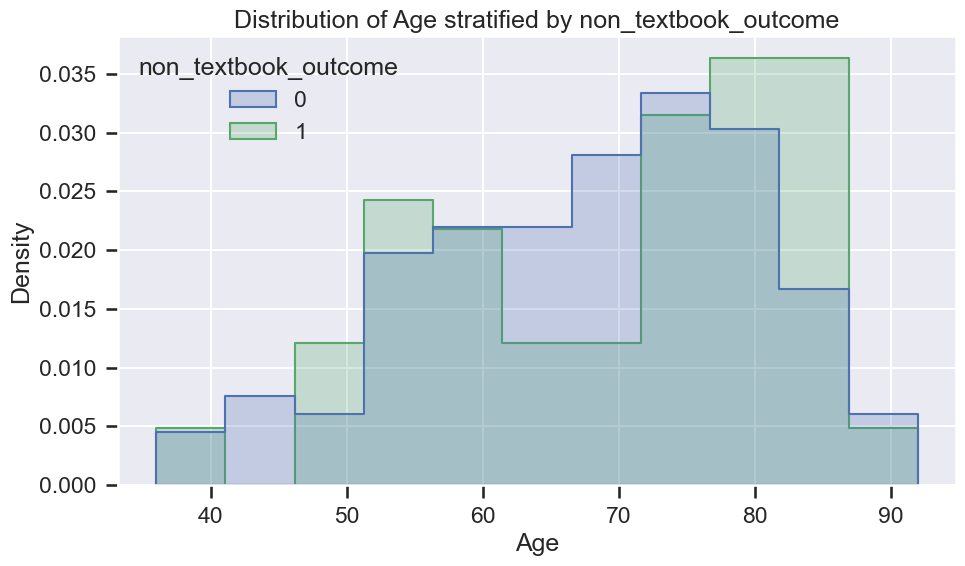

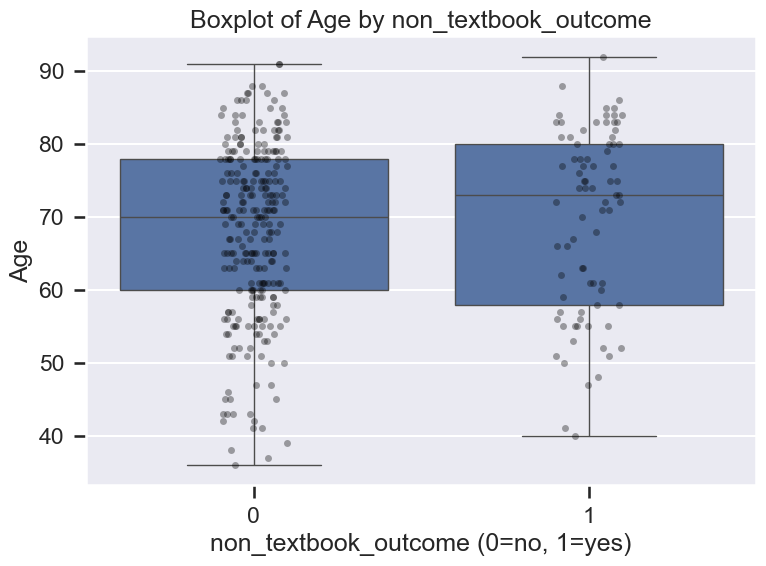

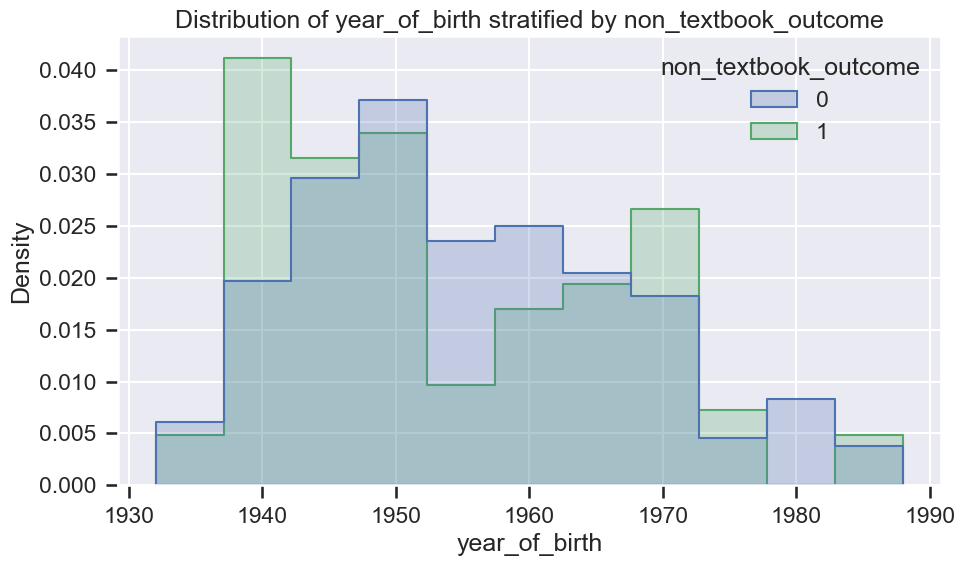

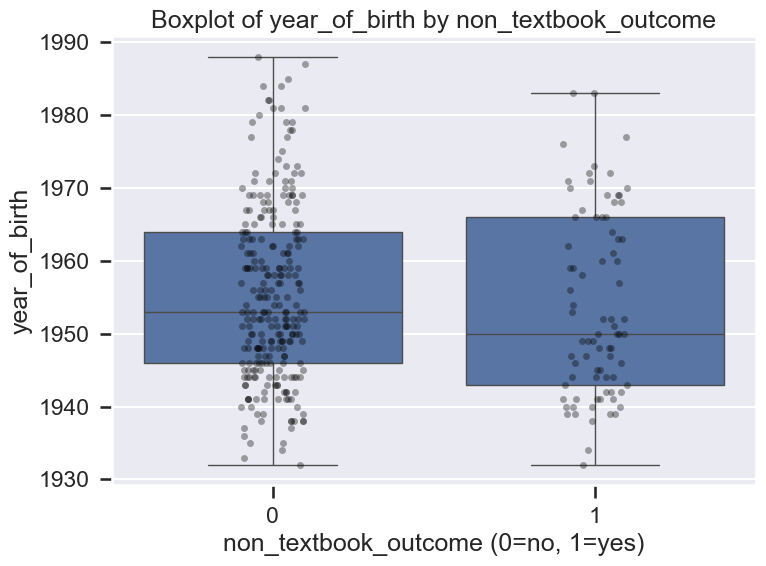

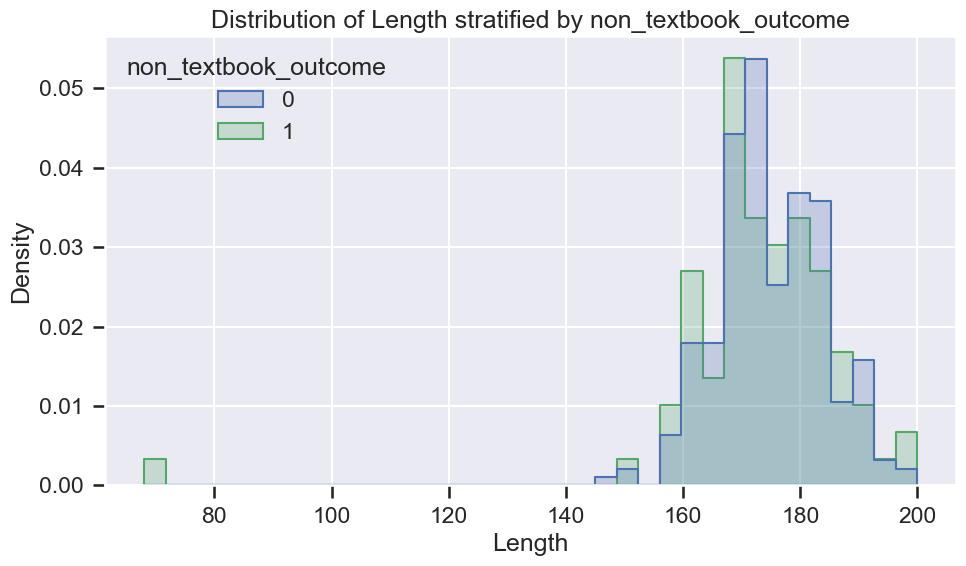

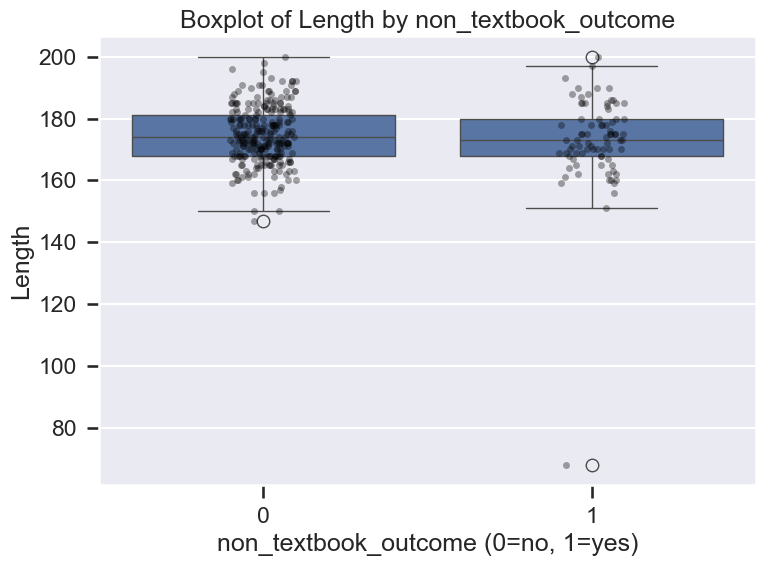

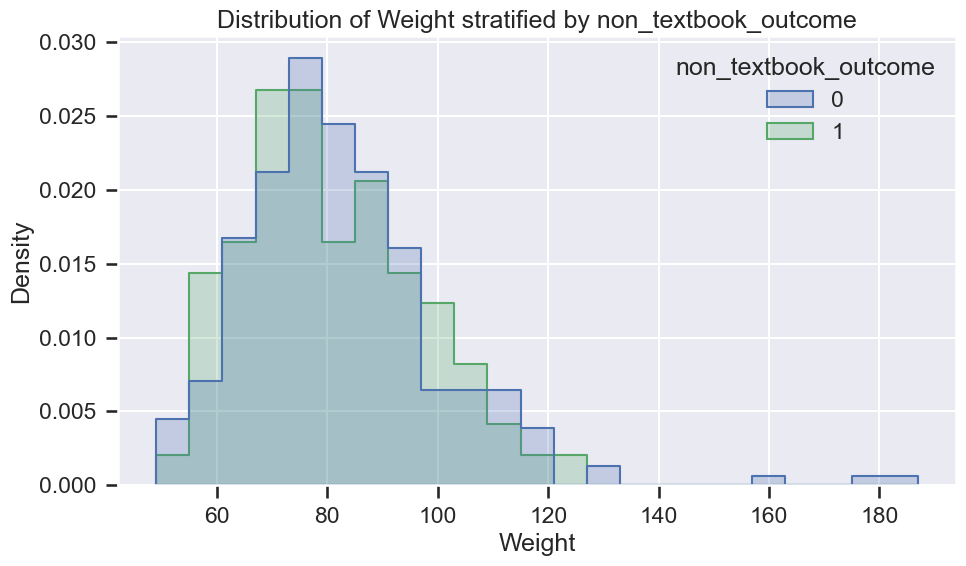

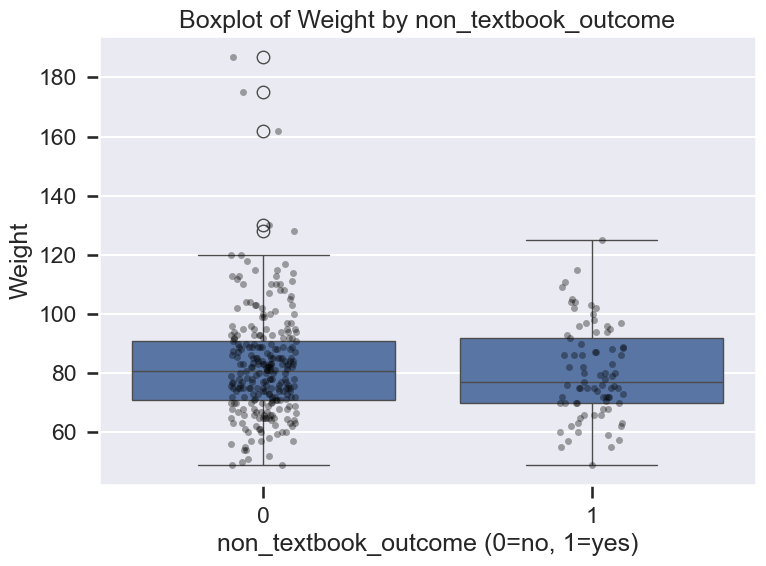

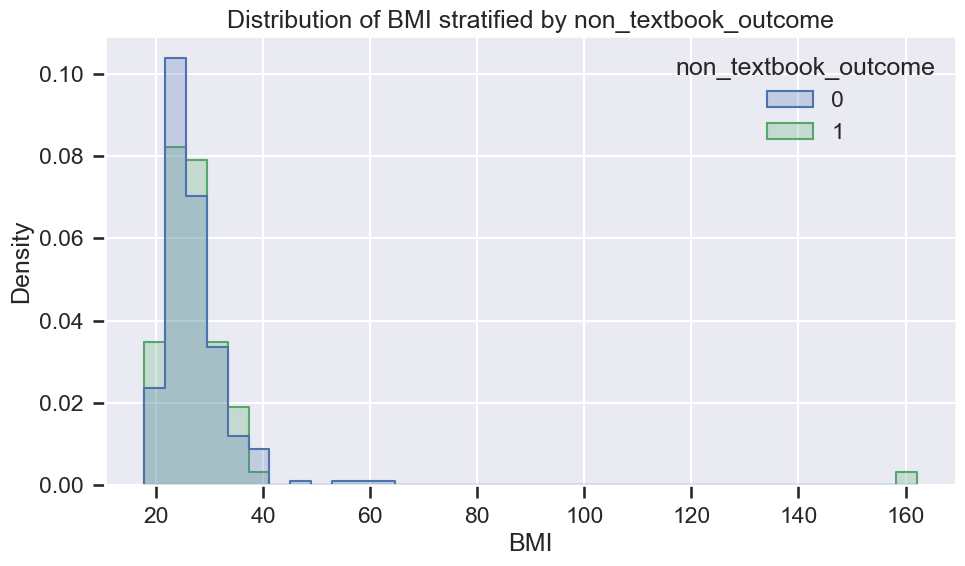

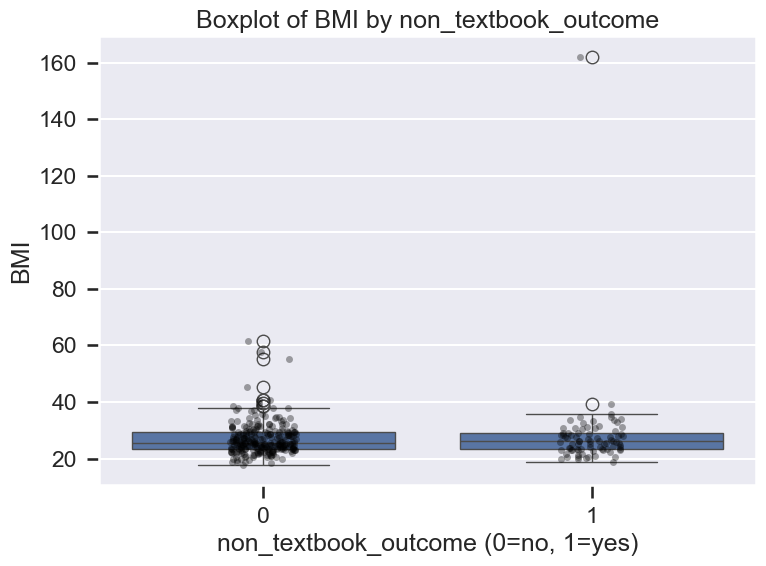

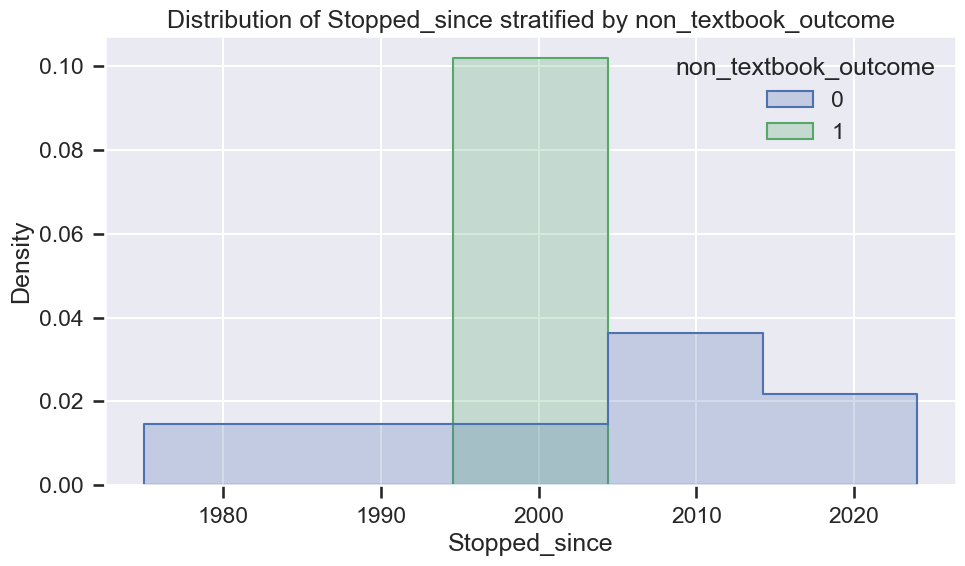

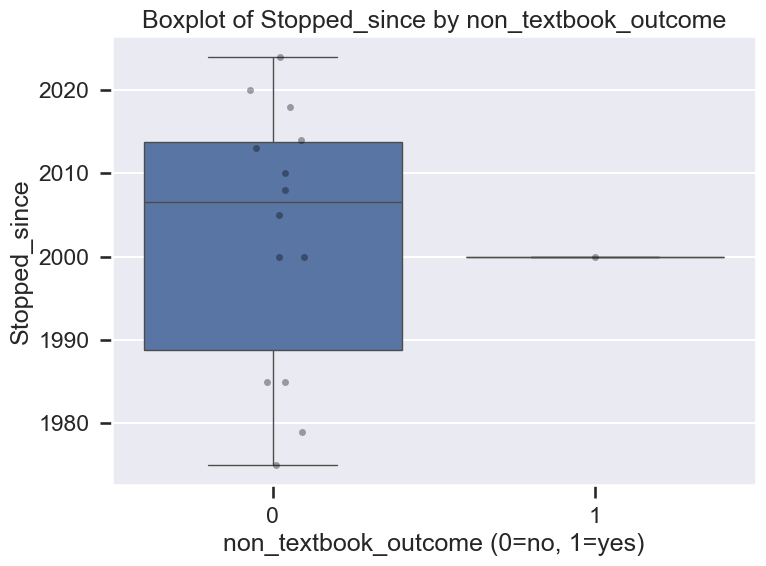

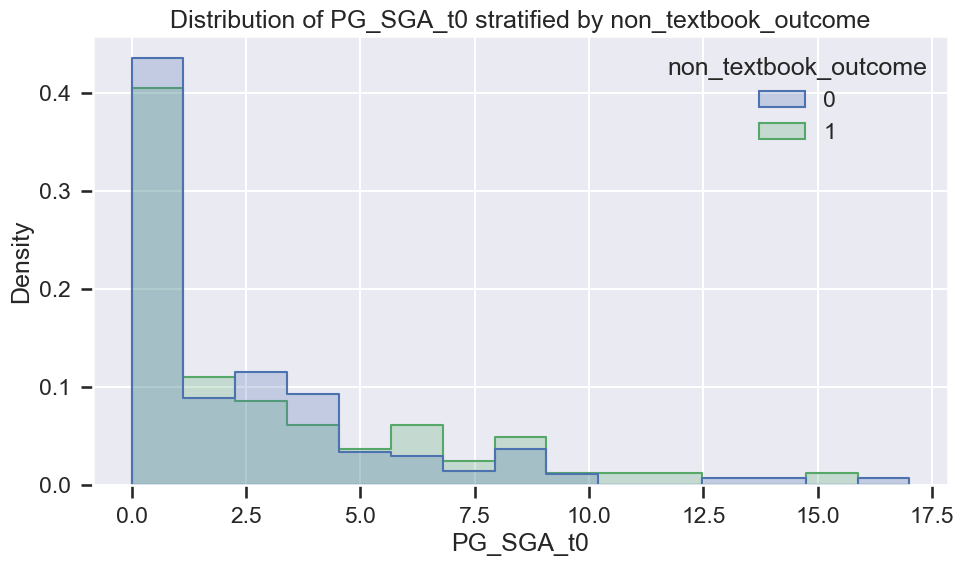

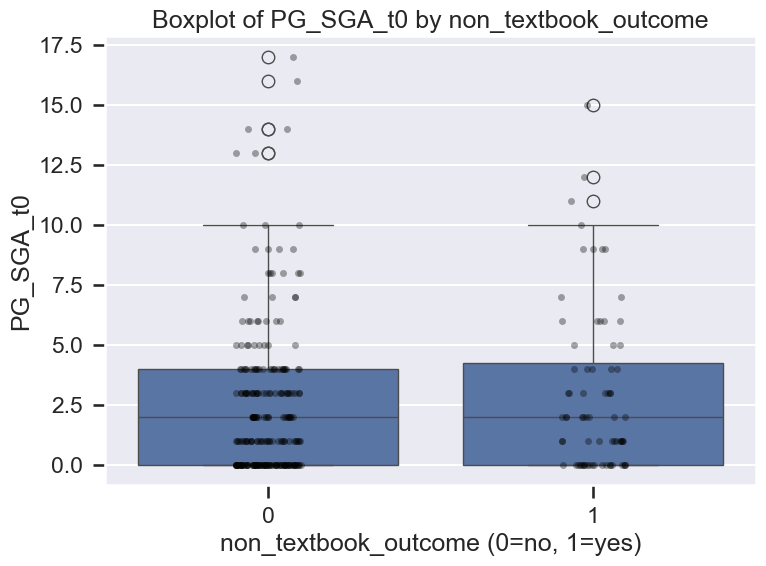

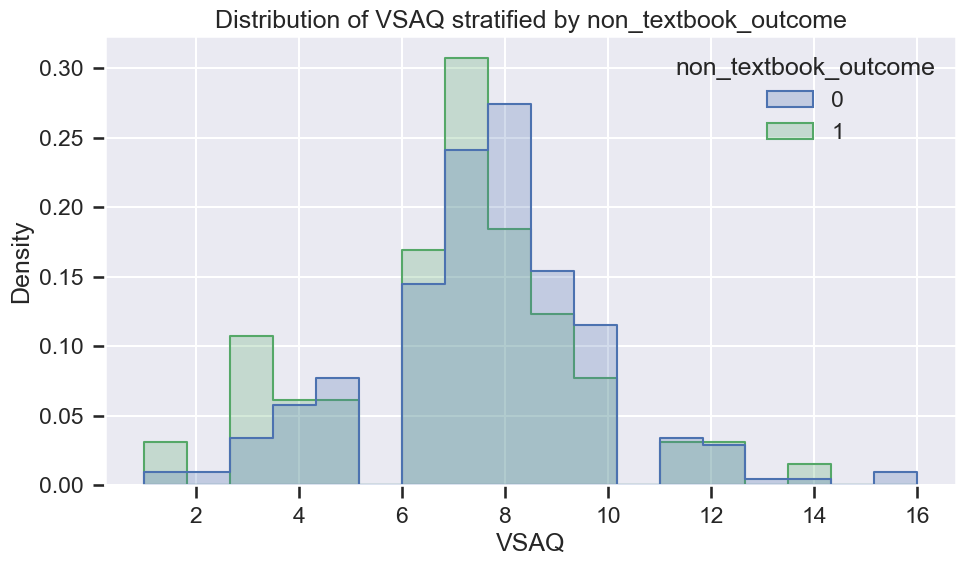

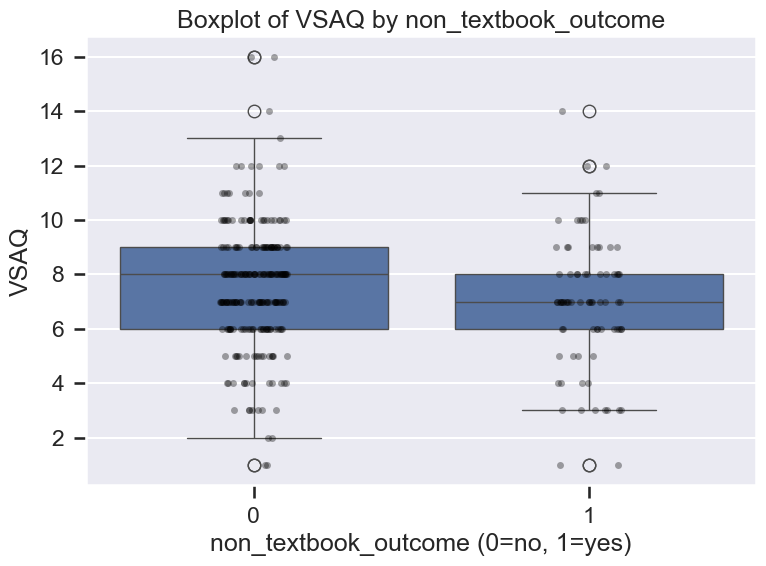

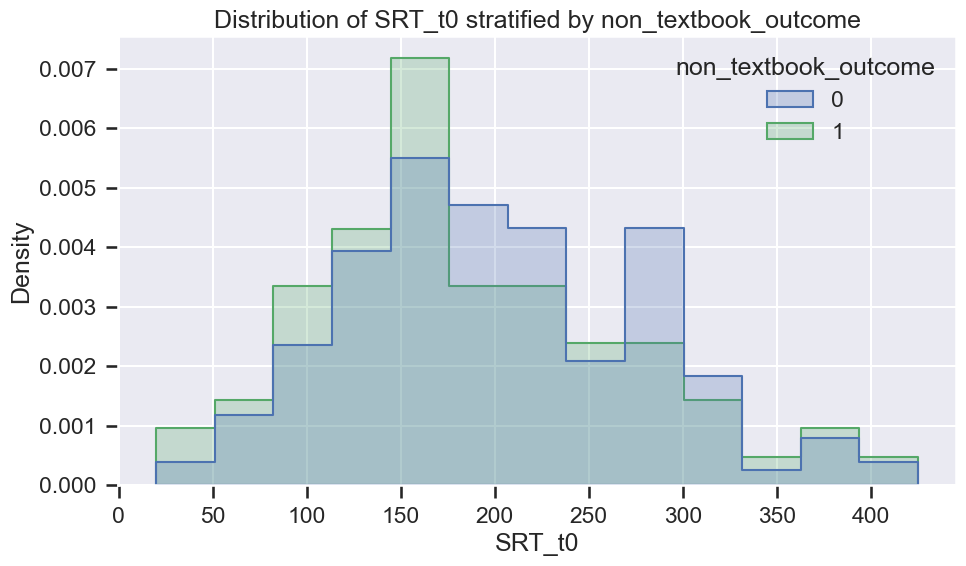

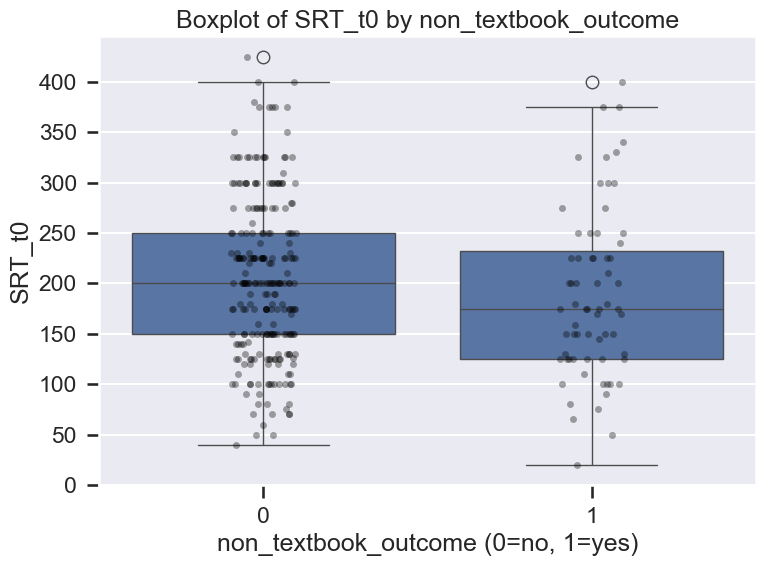

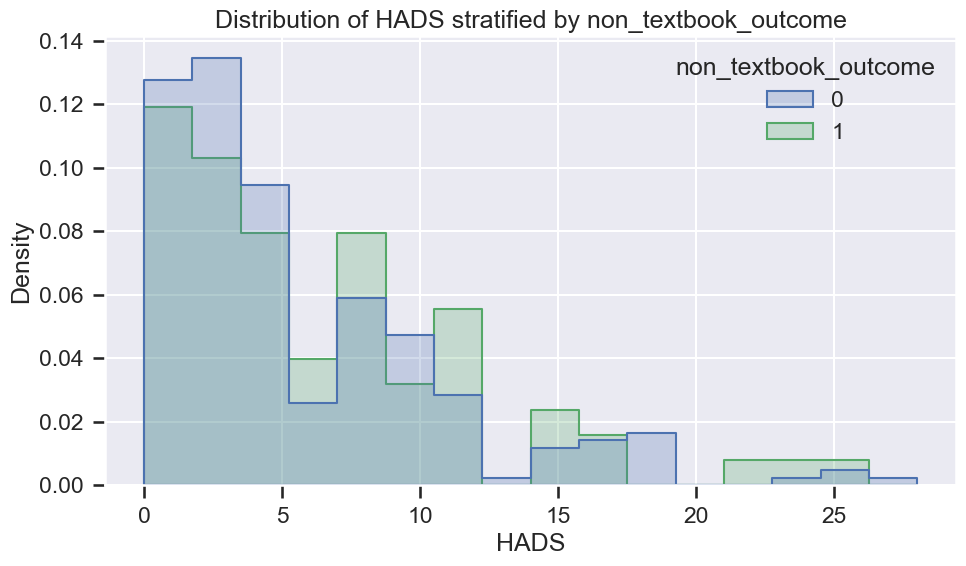

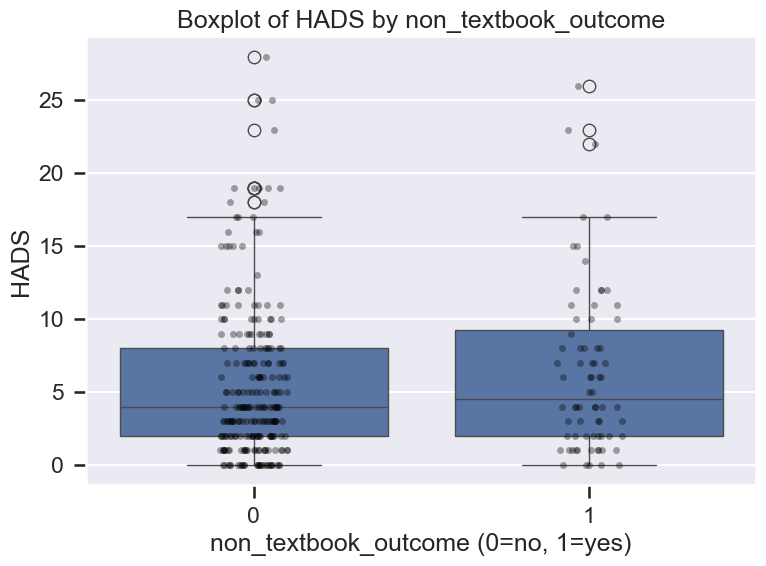

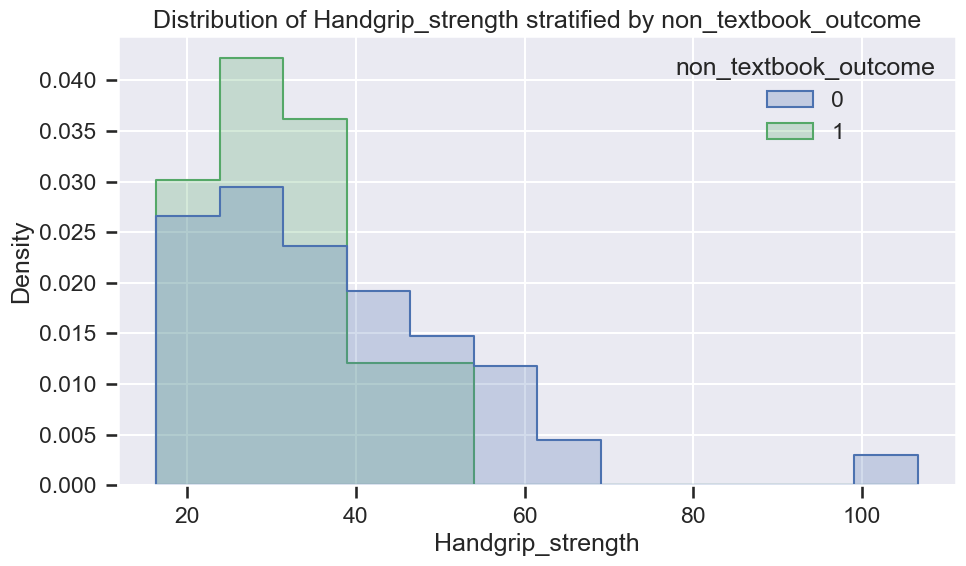

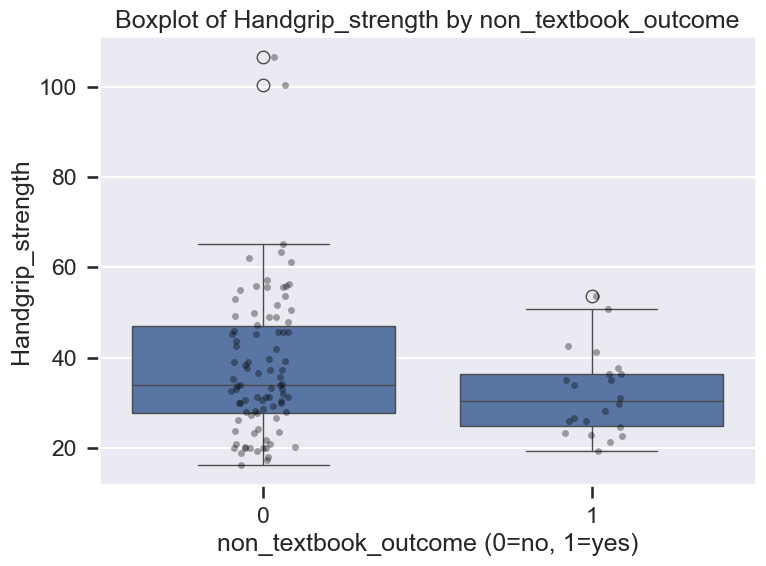

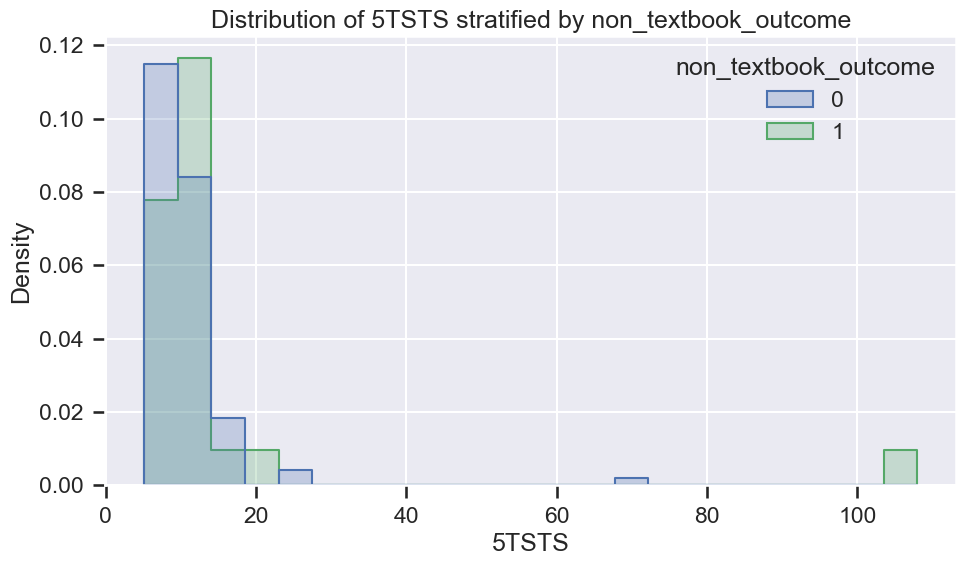

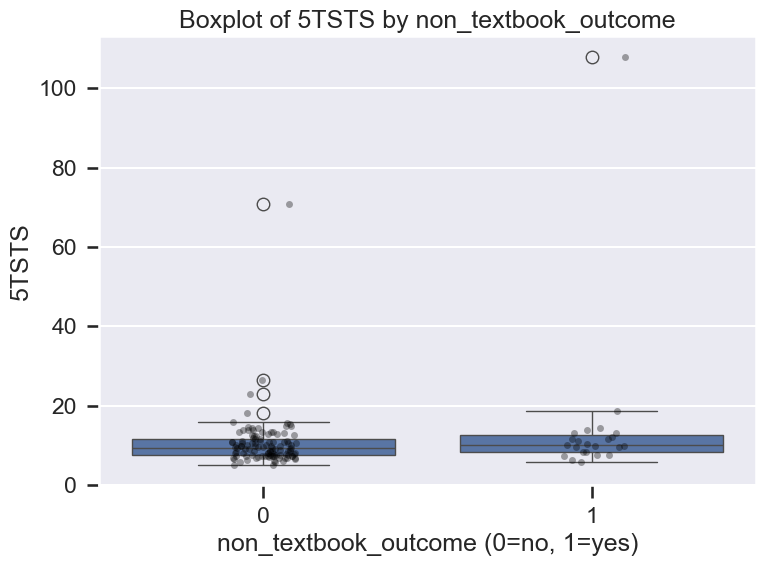

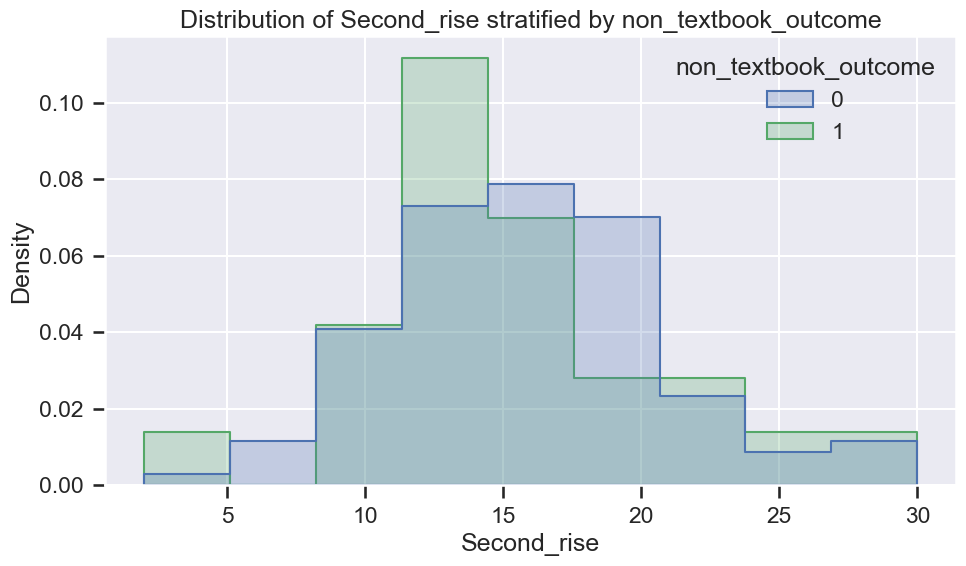

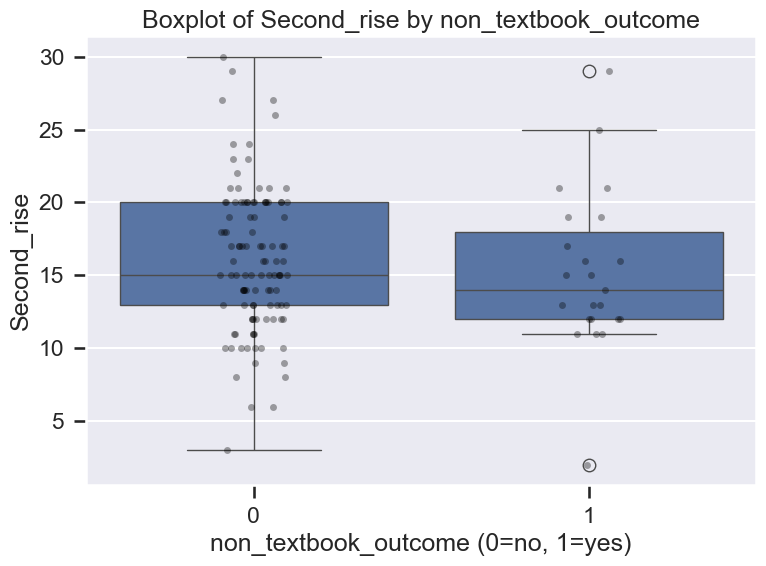

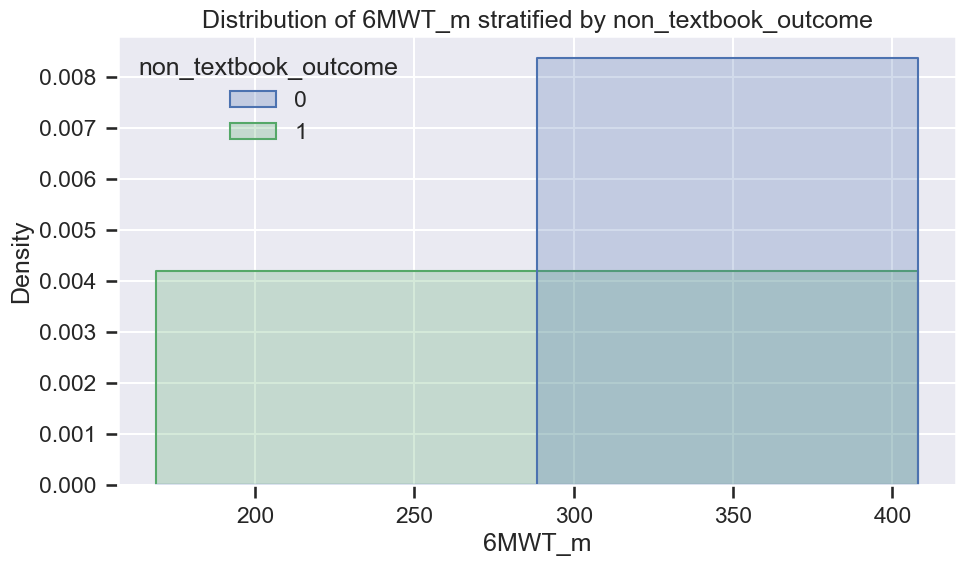

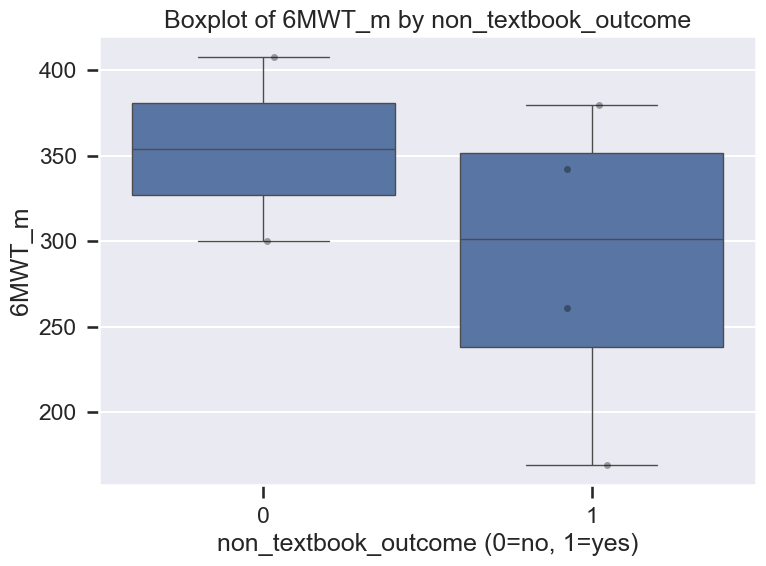

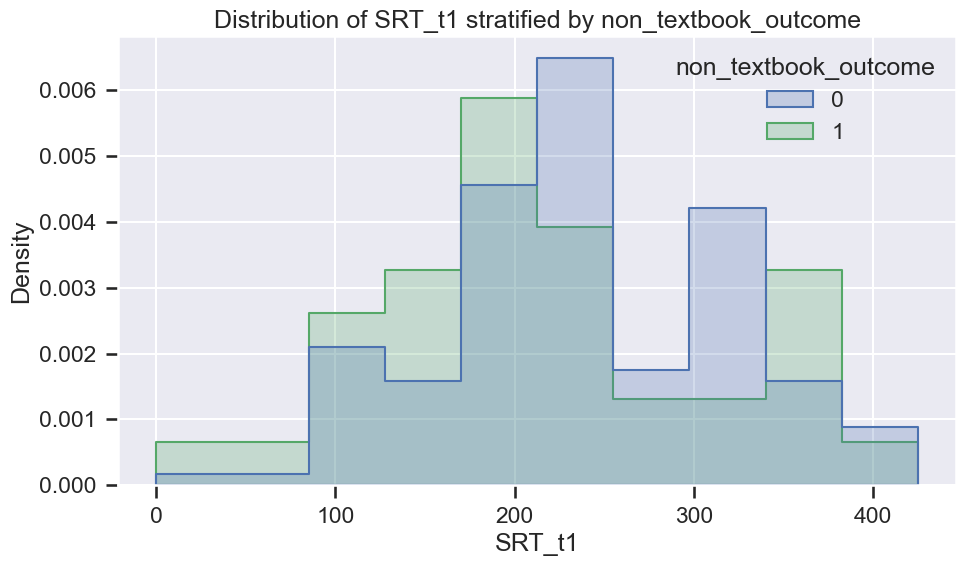

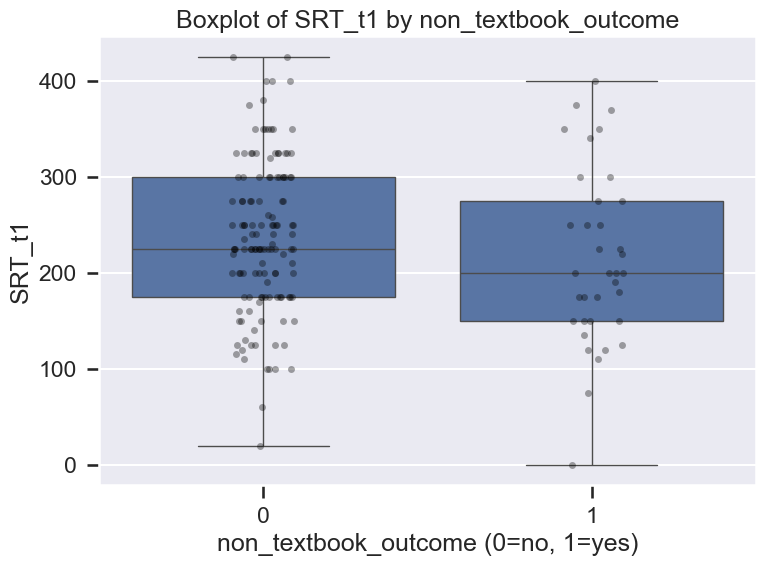

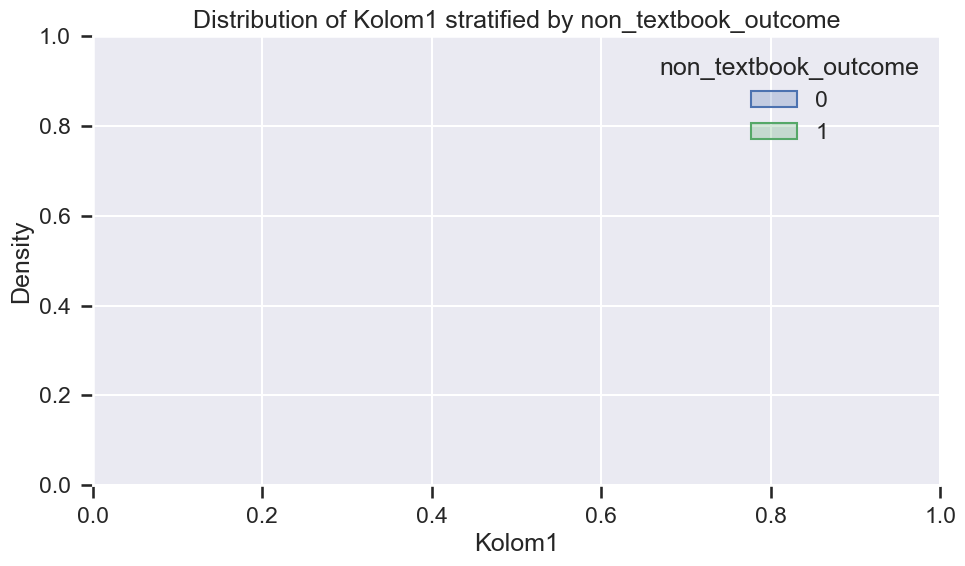

ValueError: List of boxplot statistics and `positions` values must have same the length

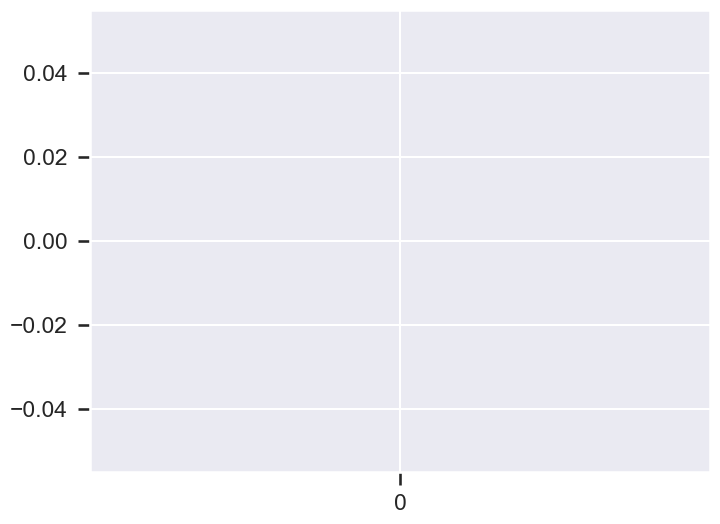

In [62]:
# Visualizations stratified by non_textbook_outcome
    # Continuous predictors: histograms and boxplots
cont_cols = [c for c in df.columns if str(df[c].dtype).startswith(('float','int')) and c != 'non_textbook_outcome']
for col in cont_cols:
        plt.figure(figsize=(10,6))
        sns.histplot(data=df, x=col, hue='non_textbook_outcome', element='step', stat='density', common_norm=False)
        plt.title(f'Distribution of {col} stratified by non_textbook_outcome')
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"hist_{col}_by_outcome.png", dpi=150)
        plt.show()

        plt.figure(figsize=(8,6))
        sns.boxplot(data=df, x='non_textbook_outcome', y=col)
        sns.stripplot(data=df, x='non_textbook_outcome', y=col, color='black', alpha=0.35)
        plt.title(f'Boxplot of {col} by non_textbook_outcome')
        plt.xlabel('non_textbook_outcome (0=no, 1=yes)')
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"box_{col}_by_outcome.png", dpi=150)
        plt.show()

    # Binary categorical predictors: stacked bar percentages
bin_cols = [c for c in df.columns if str(df[c].dtype) in ['category','object'] and df[c].nunique(dropna=True) == 2]
for col in bin_cols:
        plt.figure(figsize=(8,6))
        ct = pd.crosstab(df['non_textbook_outcome'], df[col], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set2')
        plt.title(f'{col}: percentages by non_textbook_outcome')
        plt.xlabel('non_textbook_outcome (0=no, 1=yes)')
        plt.ylabel('Percentage')
        plt.legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"stacked_{col}_by_outcome.png", dpi=150)
        plt.show()
else:
    print('Skipping visualizations: outcome or df not available.')


In [ ]:
#create a dataframe with the percentage KATZ vs non binaary outcome



### Generate PDF report

In [ ]:
top_cont = cont_tests_df.sort_values('p_value').head(15)
print("Top 15 continuous predictors by p-value:")
display(top_cont)

Top 15 continuous predictors by p-value:


,variable,test,stat,p_value,n0,n1,n_kept,n_dropped,mean0,mean1,median0,median1,cohens_d
28,Complications_number,Mann-Whitney U,6595.000000,0.000000,247,93,340,0,0.311741,1.817204e+00,0.000000,1.000000,0.906178
43,Complication_bin,Mann-Whitney U,3087.000000,0.000000,246,92,338,2,0.109756,8.369565e-01,0.000000,1.000000,2.203622
44,Reoperation_bin,Mann-Whitney U,7472.500000,0.000000,247,93,340,0,0.016194,3.655914e-01,0.000000,0.000000,1.271932
27,Duration_surgery,Mann-Whitney U,9073.000000,0.002831,247,93,340,0,188.651822,2.237204e+02,186.000000,204.000000,0.512057
26,Hb_t1,Mann-Whitney U,549.000000,0.009983,29,27,56,284,8.006896,7.240741e+00,8.400000,7.500000,-0.647247
20,HbA1c,Welch's t-test,2.790528,0.020495,10,4,14,326,50.000000,3.850000e+01,50.500000,39.000000,-1.339112
17,Transferrin,Welch's t-test,-2.188208,0.034165,102,30,132,208,2.633333,2.860000e+00,2.600000,2.750000,0.490171
14,Hb_t0,Mann-Whitney U,5129.000000,0.036872,149,58,207,133,7.897987,7.482759e+00,8.100000,7.600000,-0.326346
19,CRP,Mann-Whitney U,328.000000,0.100468,42,21,63,277,17.880952,4.147619e+01,6.500000,18.000000,0.620605
7,VSAQ,Mann-Whitney U,11653.000000,0.157887,238,89,327,13,7.495798,7.146067e+00,8.000000,7.000000,-0.150603


This cell generates a concise PDF report summarizing the descriptive analysis results. It loads the comparative test results (with effect sizes) for continuous and categorical variables, selects the top predictors by p-value, and creates formatted tables for inclusion in the PDF. The report also embeds selected figures (histograms and stacked bar charts) and provides explanatory notes on effect sizes. The PDF is saved to the output directory if all required data is available; otherwise, PDF generation is skipped.

In [ ]:
top_cat = cat_tests_df.sort_values('p_value').head(15)
print("Top 15 categorical predictors by p-value:")
display(top_cat)

Top 15 categorical predictors by p-value:


,variable,test,p_value,chi2_stat,df,levels,n_kept,n_dropped
30,Discharge_source,Chi_square,0.000050,25.001192,4.0,5,337,3
27,Surgeon,Chi_square,0.001305,35.348091,14.0,15,340,0
25,Type_surgery,Chi_square,0.019836,9.855362,3.0,4,340,0
17,Functioning,Fisher_exact(2x2),0.021023,NaN,1.0,2,272,68
49,Hb_t1_cat,Chi_square,0.030115,4.702706,1.0,2,56,284
14,Two_stairs,Chi_square,0.047577,3.924854,1.0,2,316,24
16,Personal_care,Chi_square,0.048506,7.882370,3.0,4,262,78
4,Drugs,Fisher_exact(2x2),0.073499,NaN,1.0,2,338,2
20,SRT_able,Fisher_exact(2x2),0.112906,NaN,1.0,2,322,18
23,Procedure_surgery_raw,Chi_square,0.120865,189.665892,168.0,169,340,0


In [ ]:

# Build a concise PDF report from the generated tables and plots

if Path(TABLES_DIR / 'comparative_tests_vs_outcome_effectsizes.csv').exists():
    results_df = pd.read_csv(TABLES_DIR / 'comparative_tests_vs_outcome_effectsizes.csv')
    cont = results_df[results_df['type']=='continuous'].copy()
    cat = results_df[results_df['type']=='categorical'].copy()

    # Select top variables by p-value
    top_cont = cont.sort_values('p_value').head(15)
    top_cat = cat.sort_values('p_value').head(15)

    # Prepare PDF
    pdf_path = REPORT_DIR / 'descriptive_analysis_report.pdf'
    doc = SimpleDocTemplate(str(pdf_path), pagesize=A4)
    styles = getSampleStyleSheet()
    story = []

    story.append(Paragraph('Descriptive Analysis Report', styles['Title']))
    story.append(Spacer(1, 12))
    story.append(Paragraph('Cohort summary', styles['Heading2']))
    story.append(Paragraph(f"N = {len(df)}", styles['Normal']))
    story.append(Spacer(1, 12))

    # Table: Top continuous
    story.append(Paragraph('Top Continuous Predictors vs Outcome (by p-value)', styles['Heading2']))
    cont_cols = ['variable','test','p_value','mean_diff','mean_diff_lo','mean_diff_hi','cohen_d','hedges_g','cliffs_delta']
    cont_cols = [c for c in cont_cols if c in top_cont.columns]
    data_cont_rows = [cont_cols]
    for idx, row in top_cont.iterrows():
        row_data = []
        for c in cont_cols:
            val = row.get(c)
            if pd.isna(val):
                row_data.append('')
            elif isinstance(val, (int, float)):
                row_data.append(str(round(val, 3)))
            else:
                row_data.append(str(val))
        data_cont_rows.append(row_data)
    t1 = Table(data_cont_rows, hAlign='LEFT')
    t1.setStyle(TableStyle([
        ('BACKGROUND',(0,0),(-1,0),colors.HexColor('#f0f0f0')),
        ('GRID',(0,0),(-1,-1),0.25,colors.grey),
        ('FONT',(0,0),(-1,0),'Helvetica-Bold')
    ]))
    story.append(t1)
    story.append(Spacer(1, 12))

    # Table: Top categorical
    story.append(Paragraph('Top Categorical Predictors vs Outcome (by p-value)', styles['Heading2']))
    cat_cols = ['variable','test','p_value','cramers_v','risk_ratio','risk_ratio_lo','risk_ratio_hi','odds_ratio','odds_ratio_lo','odds_ratio_hi','risk_diff','risk_diff_lo','risk_diff_hi']
    cat_cols = [c for c in cat_cols if c in top_cat.columns]
    data_cat_rows = [cat_cols]
    for idx, row in top_cat.iterrows():
        data_cat_rows.append([str(row.get(c,'' if pd.isna(row.get(c)) else row.get(c))) for c in cat_cols])
    t2 = Table(data_cat_rows, hAlign='LEFT')
    t2.setStyle(TableStyle([
        ('BACKGROUND',(0,0),(-1,0),colors.HexColor('#f0f0f0')),
        ('GRID',(0,0),(-1,-1),0.25,colors.grey),
        ('FONT',(0,0),(-1,0),'Helvetica-Bold')
    ]))
    story.append(t2)
    story.append(Spacer(1, 12))

    # Add a few plots if available
    story.append(Paragraph('Selected Figures', styles['Heading2']))
    # Try to add up to 6 figures: three histograms and three stacked bars
    figs = []
    for p in sorted(PLOTS_DIR.glob('hist_*_by_outcome.png'))[:3]:
        figs.append(p)
    for p in sorted(PLOTS_DIR.glob('stacked_*_by_outcome.png'))[:3]:
        figs.append(p)
    for p in figs:
        try:
            story.append(Image(str(p), width=500, height=300))
            story.append(Spacer(1, 12))
        except Exception:
            pass

    story.append(PageBreak())
    story.append(Paragraph('Notes', styles['Heading2']))
    story.append(Paragraph('Effect sizes: Cohens d and Hedges g for mean differences; Cliffs delta for non-parametric direction/size; Odds Ratio (OR), Risk Ratio (RR), Risk Difference (RD) with Katz/Woolf CIs for 2×2; Cramérs V for multi-level categorical predictors.', styles['Normal']))

    doc.build(story)
    print(f"PDF report written to: {pdf_path}")
else:
    print('PDF generation skipped: comparative table with effects not found.')


PDF report written to: descriptive_report\descriptive_analysis_report.pdf


In [ ]:
# create a multilevel statistical summary for a categorical variable with more than 2 levels, stratified by the binary outcome, including counts, percentages, and chi-square test results. Save the summary as a excel
#  file.
def multilevel_categorical_summary(df, cat_col, group_col='non_textbook_outcome'):
    if cat_col not in df.columns or group_col not in df.columns:
        print(f"Columns {cat_col} or {group_col} not found in DataFrame.")
        return None

    # Drop rows with missing values in either column
    df_sub = df[[cat_col, group_col]].dropna()
    n_kept = len(df_sub)
    n_dropped = len(df) - n_kept

    # Contingency table
    ct = pd.crosstab(df_sub[cat_col], df_sub[group_col])
    ct_perc = ct.div(ct.sum(axis=1), axis=0) * 100

    # Chi-square test
    try:
        chi2, p, dof, exp = stats.chi2_contingency(ct, correction=False)
        test_result = {
            'chi2_stat': float(chi2),
            'p_value': float(round(p, 6)),
            'degrees_of_freedom': int(dof)
        }
    except ValueError:
        test_result = {
            'chi2_stat': np.nan,
            'p_value': np.nan,
            'degrees_of_freedom': np.nan
        }

    # Prepare summary DataFrame
    summary_df = ct.copy()
    summary_df['total'] = summary_df.sum(axis=1)
    summary_df['percent_group0'] = ct_perc.get(0, pd.Series(0, index=ct.index))
    summary_df['percent_group1'] = ct_perc.get(1, pd.Series(0, index=ct.index))

    # Add test results as a separate row
    test_row = pd.DataFrame({
        cat_col: ['Chi-square test'],
        group_col: [''],
        'total': [''],
        'percent_group0': [''],
        'percent_group1': [''],
        'chi2_stat': [test_result['chi2_stat']],
        'p_value': [test_result['p_value']],
        'degrees_of_freedom': [test_result['degrees_of_freedom']]
    })
    
    final_df = pd.concat([summary_df.reset_index(), test_row], ignore_index=True)

    return final_df

In [ ]:

# ============================================================
# Non-responder analyse bij prehabilitatie
# - Definities: SRT / Handgrip / 5TSTS / Composite
# - GLM Binomial (HC3), Repeated Stratified CV, Bootstrap-optimismecorrectie
# - Lasso (L1) & Ridge (L2) met CV + Post-Lasso refit (OR/CI/p)
# - Outputs -> map: nonresponder_models/
# ============================================================
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.stats import scoreatpercentile

warnings.filterwarnings("ignore")

# ---------------- USER CONFIG ----------------
#DATA = "df_categorized_medical.csv"     # jouw CSV
OUTDIR = Path("nonresponder_models")
OUTDIR.mkdir(exist_ok=True)

# Kies primaire definitie: "SRT" | "Handgrip" | "5TSTS" | "composite"
PRIMARY_DEF = "composite"

# MCID / drempels voor "verbetering".
# Standaard: >0 is verbetering voor SRT/Handgrip, <0 is verbetering voor 5TSTS (kortere tijd = beter).
MCID = {
    "SRT_wkg_delta": 0.0,      # > 0 = verbetering
    "Handgrip_delta": 0.0,     # > 0 = verbetering
    "5TSTS_delta": 0.0         # < 0 = verbetering
}

# CV en bootstrap instellingen
N_SPLITS = 5
N_REPEATS = 20
B_BOOT = 500
RANDOM_STATE = 42

# Hyperparameter-roosters (inverse regularisatie C; kleiner = sterkere penaliteit)
RIDGE_C_GRID = [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
LASSO_C_GRID = [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2]

# Minimaal aantal per categorieniveau, en minimale events/non-events per niveau om scheiding te voorkomen
MIN_LEVEL_COUNT = 8
MIN_EVENTS_PER_LEVEL = 2
MIN_NONEVENTS_PER_LEVEL = 2

# Kandidaten-voorspellers (alleen meenemen als kolom bestaat)
CATEGORICALS = [
    "gender", "BMI_cat", "Tumor_location", "Type_surgery", "Elective", "iron_category"
]
CONTINUOUS = [
    "Age", "Surgery_asa_num", "SRT_t0_wkg", "Handgrip_strength", "5TSTS", "number_sessions"
]
# -----------------------------------------------------------





def make_nonresponder_flags(df: pd.DataFrame, mcid: dict):
    """
    Maakt domeinspecifieke non-responder vlaggen en composiet:
      - nonresponder_SRT: 1 als SRT_wkg_delta ≤ MCID_SRT; anders 0
      - nonresponder_HG : 1 als Handgrip_delta ≤ MCID_HG;  anders 0
      - nonresponder_5T : 1 als 5TSTS_delta ≥ MCID_5T;    anders 0
      - nonresponder_any: 1 als alle drie non-responder;   anders 0
    """
    for col in ["SRT_wkg_delta", "Handgrip_delta", "5TSTS_delta"]:
        if col not in df.columns:
            df[col] = np.nan

    df["nonresponder_SRT"] = np.where(
        pd.to_numeric(df["SRT_wkg_delta"], errors="coerce") <= mcid["SRT_wkg_delta"], 1, 0
    )
    df["nonresponder_HG"] = np.where(
        pd.to_numeric(df["Handgrip_delta"], errors="coerce") <= mcid["Handgrip_delta"], 1, 0
    )
    # 5TSTS: verbetering = daling (negatief); non-responder als delta >= drempel (meestal 0)
    df["nonresponder_5T"] = np.where(
        pd.to_numeric(df["5TSTS_delta"], errors="coerce") >= mcid["5TSTS_delta"], 1, 0
    )

    df["nonresponder_any"] = np.where(
        (df["nonresponder_SRT"] == 1) &
        (df["nonresponder_HG"] == 1) &
        (df["nonresponder_5T"] == 1),
        1, 0
    )
    return df


def choose_outcome_column(primary_def: str) -> str:
    if primary_def.lower() == "srt":
        return "nonresponder_SRT"
    if primary_def.lower() == "handgrip":
        return "nonresponder_HG"
    if primary_def.lower() == "5tsts":
        return "nonresponder_5T"
    return "nonresponder_any"


def collapse_rare_levels(s: pd.Series, min_count=8) -> pd.Series:
    vc = s.value_counts(dropna=False)
    rare = set(vc[vc < min_count].index)
    if not rare:
        return s.astype("category")
    return s.apply(lambda v: "Other" if (pd.isna(v) or v in rare) else v).astype("category")


def collapse_zero_cells(x: pd.Series, y: pd.Series,
                        min_events=2, min_nonevents=2) -> pd.Series:
    """
    Voor elke categorie met < min_events of < min_nonevents → samenvoegen tot 'Other'.
    """
    s = x.astype("category")
    tab = pd.crosstab(s, y)
    to_other = set()
    for lvl in tab.index:
        e = tab.loc[lvl, 1] if 1 in tab.columns else 0
        n = tab.loc[lvl, 0] if 0 in tab.columns else 0
        if e < min_events or n < min_nonevents:
            to_other.add(lvl)
    if not to_other:
        return s
    return s.apply(lambda v: "Other" if v in to_other else v).astype("category")


def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    mu = s.mean(skipna=True)
    sd = s.std(skipna=True, ddof=1)
    if sd and sd > 0:
        return (s - mu) / sd
    return s * np.nan


def present_columns(df, cols):
    return [c for c in cols if c in df.columns]


def build_formula(outcome, cont_cols, cat_cols):
    terms = [f"z_{c}" for c in cont_cols] + [f"C({c})" for c in cat_cols]
    return f"{outcome} ~ " + " + ".join(terms)


def table1_compare(df, outcome, cont_cols, cat_cols, outpath: Path):
    """
    Tabel 1 (responder vs non-responder in prehab) met
    - gemiddelden/SD voor continue
    - verdelingen voor categorische
    """
    records = []
    for c in cont_cols:
        if c not in df.columns:
            continue
        grp = df.groupby(outcome)[c].agg(['mean', 'std', 'count'])
        grp.columns = [f"{c}_mean", f"{c}_sd", f"{c}_n"]
        row0 = { "outcome": 0, **{k: grp.loc[0, k] if 0 in grp.index else np.nan for k in grp.columns} }
        row1 = { "outcome": 1, **{k: grp.loc[1, k] if 1 in grp.index else np.nan for k in grp.columns} }
        records.extend([row0, row1])

    cont_df = pd.DataFrame(records)
    cont_df.to_csv(outpath / "table1_continuous.csv", index=False)

    # Categorische verdelingen
    cat_frames = []
    for c in cat_cols:
        if c not in df.columns:
            continue
        ct = pd.crosstab(df[c], df[outcome], normalize="columns") * 100.0
        ct.to_csv(outpath / f"table1_categorical_{c}.csv")
        cat_frames.append(ct)
    return cont_df


def fit_glm_hc3(y, X):
    glm = sm.GLM(y, X, family=sm.families.Binomial())
    res = glm.fit()
    res_rob = res.get_robustcov_results(cov_type="HC3", use_t=False)
    return res_rob


def or_table_from_sm(res_like: sm.GLM) -> pd.DataFrame:
    params = res_like.params
    conf = res_like.conf_int()
    out = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "OR": np.exp(params.values),
        "CI_low": np.exp(conf[0].values),
        "CI_high": np.exp(conf[1].values),
        "p_value": res_like.pvalues.values
    })
    return out.sort_values("p_value")


def apparent_perf(res_like, X, y) -> dict:
    yhat = res_like.predict(X)
    auc = roc_auc_score(y, yhat)
    brier = brier_score_loss(y, yhat)
    return {"AUC": auc, "Brier": brier}


def cv_perf_glm(X_df, y_arr, n_splits=5, n_repeats=20, random_state=42) -> dict:
    """
    Refit GLM per fold (statsmodels) en bereken AUC/Brier op test.
    """
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    aucs, briers = []
    for tr, te in rskf.split(X_df, y_arr):
        Xtr, ytr = X_df.iloc[tr], y_arr[tr]
        Xte, yte = X_df.iloc[te], y_arr[te]
        res = fit_glm_hc3(ytr, Xtr)
        yhat = res.predict(Xte)
        aucs.append(roc_auc_score(yte, yhat))
        briers.append(brier_score_loss(yte, yhat))
    return {
        "AUC_mean": float(np.mean(aucs)),
        "AUC_CI": (float(scoreatpercentile(aucs, 2.5)), float(scoreatpercentile(aucs, 97.5))),
        "Brier_mean": float(np.mean(briers)),
        "Brier_CI": (float(scoreatpercentile(briers, 2.5)), float(scoreatpercentile(briers, 97.5))),
    }


def bootstrap_optimism_harrell(X_df, y_arr, B=500, seed=12345) -> dict:
    """
    Harrell's optimism-correctie:
      - Fit op bootstrap → apparent_boot
      - Test op origineel → test_on_orig
      - Optimisme = apparent_boot - test_on_orig
      - Corrected = apparent_full - mean(optimism)
    """
    rng = np.random.default_rng(seed)
    # Apparent op full data
    full = fit_glm_hc3(y_arr, X_df)
    yhat_full = full.predict(X_df)
    apparent_auc = roc_auc_score(y_arr, yhat_full)
    apparent_brier = brier_score_loss(y_arr, yhat_full)

    opt_aucs, opt_briers = [], []
    n = X_df.shape[0]
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        Xb = X_df.iloc[idx]
        yb = y_arr[idx]
        res_b = fit_glm_hc3(yb, Xb)
        # apparent on bootstrap
        yhat_app = res_b.predict(Xb)
        auc_app = roc_auc_score(yb, yhat_app)
        brier_app = brier_score_loss(yb, yhat_app)
        # test on original
        yhat_test = res_b.predict(X_df)
        auc_test = roc_auc_score(y_arr, yhat_test)
        brier_test = brier_score_loss(y_arr, yhat_test)
        opt_aucs.append(auc_app - auc_test)
        opt_briers.append(brier_app - brier_test)

    auc_corr = apparent_auc - float(np.mean(opt_aucs))
    brier_corr = apparent_brier - float(np.mean(opt_briers))
    auc_corr_ci = (
        float(scoreatpercentile([apparent_auc - o for o in opt_aucs], 2.5)),
        float(scoreatpercentile([apparent_auc - o for o in opt_aucs], 97.5))
    )
    brier_corr_ci = (
        float(scoreatpercentile([apparent_brier - o for o in opt_briers], 2.5)),
        float(scoreatpercentile([apparent_brier - o for o in opt_briers], 97.5))
    )
    return {
        "apparent": {"AUC": apparent_auc, "Brier": apparent_brier},
        "optimism_corrected": {
            "AUC": auc_corr, "AUC_CI": auc_corr_ci,
            "Brier": brier_corr, "Brier_CI": brier_corr_ci
        },
        "B": B
    }


def cv_penalized(X, y, penalty="l2", C_grid=None, n_splits=5, n_repeats=20, seed=42):
    """
    CV-prestatie voor L1/L2 (sklearn LogisticRegression, solver='saga')
    Return: best_C, cv_mean_auc, cv_mean_brier, coef op full fit (met best_C)
    """
    if C_grid is None:
        C_grid = [0.1, 0.5, 1, 2, 5]
    solver = "saga"  # ondersteunt l1 en l2
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)

    best = {"C": None, "AUC": -np.inf, "Brier": np.inf}
    for C in C_grid:
        aucs, briers = []
        for tr, te in rskf.split(X, y):
            clf = LogisticRegression(
                penalty=penalty, C=C, solver=solver, max_iter=5000, random_state=seed,
                fit_intercept=True, n_jobs=None
            )
            clf.fit(X[tr], y[tr])
            proba = clf.predict_proba(X[te])[:, 1]
            aucs.append(roc_auc_score(y[te], proba))
            briers.append(brier_score_loss(y[te], proba))
        auc_m = float(np.mean(aucs))
        brier_m = float(np.mean(briers))
        # kies op hoogste AUC; bij gelijke AUC kies lagere Brier; bij gelijke Brier kies hogere C
        better = (auc_m > best["AUC"] + 1e-12) or \
                 (abs(auc_m - best["AUC"]) <= 1e-12 and (brier_m < best["Brier"] - 1e-12 or
                                                         (abs(brier_m - best["Brier"]) <= 1e-12 and C > (best["C"] or 0))))
        if better:
            best = {"C": C, "AUC": auc_m, "Brier": brier_m}

    # Fit op full data met best C
    clf_full = LogisticRegression(
        penalty=penalty, C=best["C"], solver=solver, max_iter=5000, random_state=seed,
        fit_intercept=True
    )
    clf_full.fit(X, y)
    return best, clf_full


def post_lasso_refit_statsmodels(X_df, y_arr, lasso_clf, feature_names) -> pd.DataFrame:
    """
    Bepaal geselecteerde features (niet-nul coefs), refit GLM (HC3) en geef OR/CI/p
    """
    coefs = lasso_clf.coef_.ravel()
    sel_mask = np.abs(coefs) > 1e-8
    # Intercept kolom in X_df? (patsy design bevat intercept-kolom 'Intercept')
    keep_cols = []
    for i, name in enumerate(feature_names):
        if sel_mask[i]:
            keep_cols.append(name)
    # Intercept altijd meenemen als aanwezig
    if "Intercept" in X_df.columns and "Intercept" not in keep_cols:
        keep_cols = ["Intercept"] + keep_cols
    if not keep_cols:
        return pd.DataFrame({"term": [], "OR": [], "CI_low": [], "CI_high": [], "p_value": []})

    X_sel = X_df[keep_cols]
    res_sel = fit_glm_hc3(y_arr, X_sel)
    return or_table_from_sm(res_sel)



print("==> Data inlezen ...")
    #df = load_data(DATA)
     
    # Alleen prehab-patiënten
df = df[df.get("prehab_j_n", 0) == 1].copy()

    # Definieer non-responder vlaggen
df = make_nonresponder_flags(df, MCID)
outcome_col = choose_outcome_column(PRIMARY_DEF)

    # Kandidaten-voorspellers (alleen bestaande)
cont = present_columns(df, CONTINUOUS)
cats = present_columns(df, CATEGORICALS)

    # --- Opschonen categorisch: zeldzame levels -> 'Other', en lege cellen vermijden
y_tmp = pd.to_numeric(df[outcome_col], errors="coerce")
for c in cats:
        s = df[c].astype("object")
        s = collapse_rare_levels(s, min_count=MIN_LEVEL_COUNT)
        s = collapse_zero_cells(s, y_tmp, min_events=MIN_EVENTS_PER_LEVEL, min_nonevents=MIN_NONEVENTS_PER_LEVEL)
        df[c] = s

    # --- Z-scores voor continue variabelen
for c in cont:
        df[f"z_{c}"] = zscore(df[c])

    # --- Maak complete-case subset voor model
needed = [outcome_col] + [f"z_{c}" for c in cont] + cats
dfm = df[needed].dropna(axis=0, how="any").copy()
N = len(dfm)
print(f"Observaties (prehab, complete case): N = {N}")

    # --- Patsy design matrices
formula = build_formula(outcome_col, cont, cats)
y, X = patsy.dmatrices(formula, dfm, return_type="dataframe")
y = np.asarray(y).ravel().astype(int)

    # --- Tabel 1 (ter vergelijking responders vs non-responders)
print("Tabel 1 opslaan ...")
table1_compare(dfm.assign(**{outcome_col: y}), outcome_col, cont, cats, OUTDIR)

    # ====== GLM (HC3) ======
#print("Fit GLM Binomial (HC3-robuste SE) ...")
###or_glm.to_csv(OUTDIR / "glm_hc3_OR_table.csv", index=False)

# Apparent prestatie
perf_app = apparent_perf(res_glm, X, y)

    # CV-prestatie (refit per fold)
print("CV-prestatie (5x20) schatten ...")
perf_cv = cv_perf_glm(X, y, n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)

    # Bootstrap-optimismecorrectie
print(f"Bootstrap optimismecorrectie (B={B_BOOT}) ...")
perf_boot = bootstrap_optimism_harrell(X, y, B=B_BOOT, seed=RANDOM_STATE)

    # ====== Ridge (L2) ======
print("Ridge (L2) CV-grid ...")
X_np = X.values
best_ridge, ridge_full = cv_penalized(
          X_np, y, penalty="l2", C_grid=RIDGE_C_GRID,
        n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=RANDOM_STATE
    )
    # Bewaar coefs
ridge_coefs = pd.DataFrame({"term": X.columns, "coef": ridge_full.coef_.ravel()})
ridge_coefs.to_csv(OUTDIR / f"ridge_coefs_C_{best_ridge['C']}.csv", index=False)

    # ====== Lasso (L1) + post-lasso refit ======
print("Lasso (L1) CV-grid ...")
best_lasso, lasso_full = cv_penalized(
        X_np, y, penalty="l1", C_grid=LASSO_C_GRID,
        n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=RANDOM_STATE
    )
lasso_coefs = pd.DataFrame({"term": X.columns, "coef": lasso_full.coef_.ravel()})
lasso_coefs.to_csv(OUTDIR / f"lasso_raw_coefs_C_{best_lasso['C']}.csv", index=False)

    # Post-lasso refit met statsmodels (alleen geselecteerde features)
print("Post-lasso refit (GLM HC3) ...")
or_post_lasso = post_lasso_refit_statsmodels(X, y, lasso_full, X.columns)
or_post_lasso.to_csv(OUTDIR / "lasso_post_refit_OR_table.csv", index=False)

    # ====== Samenvatting wegschrijven ======
summary = {
        "N": N,
        "primary_definition": PRIMARY_DEF,
        "formula_glm": formula,
        "glm_apparent_auc": perf_app["AUC"],
        "glm_apparent_brier": perf_app["Brier"],
        "cv_auc_mean": perf_cv["AUC_mean"],
        "cv_auc_ci_low": perf_cv["AUC_CI"][0],
        "cv_auc_ci_high": perf_cv["AUC_CI"][1],
        "cv_brier_mean": perf_cv["Brier_mean"],
        "cv_brier_ci_low": perf_cv["Brier_CI"][0],
        "cv_brier_ci_high": perf_cv["Brier_CI"][1],
        "boot_B": perf_boot["B"],
        "boot_auc_corr": perf_boot["optimism_corrected"]["AUC"],
        "boot_auc_ci_low": perf_boot["optimism_corrected"]["AUC_CI"][0],
        "boot_auc_ci_high": perf_boot["optimism_corrected"]["AUC_CI"][1],
        "boot_brier_corr": perf_boot["optimism_corrected"]["Brier"],
        "boot_brier_ci_low": perf_boot["optimism_corrected"]["Brier_CI"][0],
        "boot_brier_ci_high": perf_boot["optimism_corrected"]["Brier_CI"][1],
        "ridge_best_C": best_ridge["C"],
        "ridge_cv_auc": best_ridge["AUC"],
        "ridge_cv_brier": best_ridge["Brier"],
        "lasso_best_C": best_lasso["C"],
        "lasso_cv_auc": best_lasso["AUC"],
        "lasso_cv_brier": best_lasso["Brier"]
    }
pd.DataFrame([summary]).to_csv(OUTDIR / "summary_metrics.csv", index=False)

print("\n=== KLAAR ===")
print(f"Outputs opgeslagen in: {OUTDIR.resolve()}")
print(f"- GLM OR/CI/p : {OUTDIR/'glm_hc3_OR_table.csv'}")
print(f"- Post-Lasso OR/CI/p : {OUTDIR/'lasso_post_refit_OR_table.csv'}")
print(f"- CV/Bootstrap samenvatting : {OUTDIR/'summary_metrics.csv'}")
print(f"- Coefs Ridge/Lasso : {OUTDIR/'ridge_coefs_C_'+str(best_ridge['C'])+'.csv'}, "
      f"{OUTDIR/'lasso_raw_coefs_C_'+str(best_lasso['C'])+'.csv'}")



==> Data inlezen ...


KeyError: False

## Outputs
- **Tables** (`descriptive_report/tables/`):
  - `continuous_summary.csv` — descriptive stats per continuous variable.
  - `categorical_overview.csv` — counts & levels per categorical variable.
  - `categorical_{var}.csv` — frequency tables per categorical variable.
  - `comparative_tests_vs_outcome_effectsizes.csv` — tests **with effect sizes**.
  - `2x2_{var}_vs_outcome.csv` — 2×2 contingency tables for binary predictors.
- **Plots** (`descriptive_report/plots/`): histograms, boxplots, stacked bar charts.
- **PDF**: `descriptive_report/descriptive_analysis_report.pdf` — compact report of tables & selected figures.
